Attacker and Defender strategy simaltaneous optimization

0. Setup
- Operation area's characteristics are globally shared
i.e. map bound, defender's search pattern, static obstacle locations, etc

1. Attacker optimiztaion (Joseph)
- Attacker generates initial guess based on setup

2. Defender optimization (Jeff)
- Defender optimize based on attacker's opitmized path

In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time
import math

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

# Import Customized python classes
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera
import Dynamic
import STP_RRTStar
import convex_map

importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar)
from STP_RRTStar import STP_RRTStar as rrt

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
from datetime import datetime

# Generate current timestamp
now = datetime.now()

# Format: YYYYMMDD_HHMMSS (e.g., 20251230_131500)
timestamp = now.strftime("%Y%m%d_%H%M%S")

In [3]:
# General Setup of World Parameter288
map_size = (100, 100)
num_buildings = 8
num_direc_sensor = 5
num_omni_sensor = 5
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(30)
max_range = 25
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
# rng_seed = 262
# rng_seed = 284 # This value osciliates
# rng_seed = 178
# rng_seed = 283 # Another oscilation
# rng_seed = rn.randint(1, 10000)
# rng_seed = 111 # Strong Oscillation // good
# rng_seed = 766 # oscilates
# rng_seed = 475 # Oscillates 
# rng_seed = 786
# rng_seed = 5942 # << another good good
rng_seed = 4134 # << This was GOOOD
print(rng_seed)

4134


(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

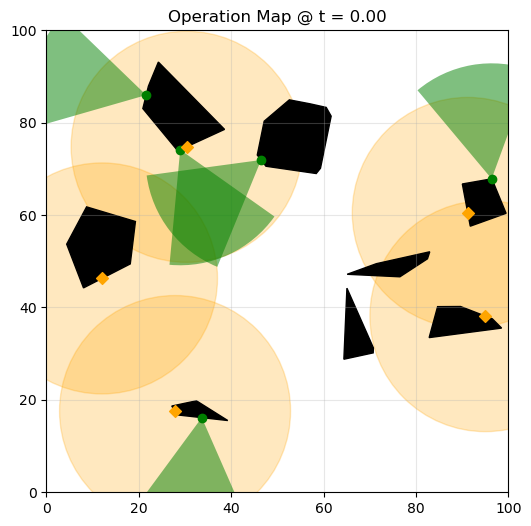

In [4]:
# Generate map
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

# Parse map_in dictionarymap_size_val*0.1
map_size = map_in['st']['size']

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [5]:
# Setup for Attacker Strategy: STP-RRT*
x0 = [0, 0, 0]
xf = [100, 100, 360]
vmax = 10

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

In [6]:
# Generate Dynamic Map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1

Initial Attacker Path generation with STP-RRT*
- if run_rrt = True: Run a new attacker path
- if run_rrt = False: load old attacker path

STP-RRT* initialized
Total Cost: 0.0


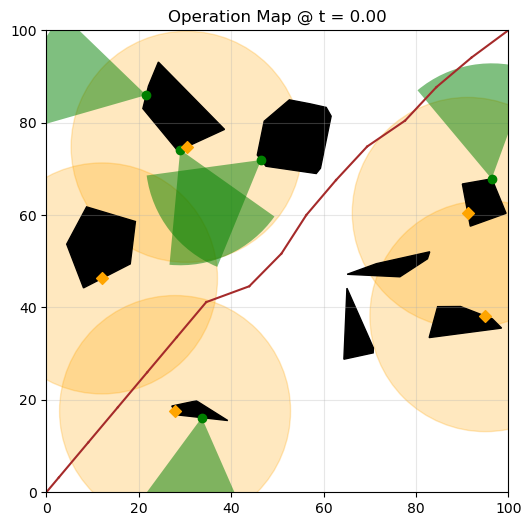

In [7]:
run_rrt = False
debug = True

# Initialize STP-RRT* Notebook
rrt_alg = rrt(vmax=vmax, xf=xf, map_size=map_size, vehicle=vehicle, cam_dict=cam_dict, dmap=dmap, max_time=1, map_in=map_in)

if run_rrt:
    
    # Run STP-RRT*
    # STP-RRT* Execution parameters
    x0 = x0          # start point
    nPartition = 5          # number of trees from the end point
    compTimeLimit = 300     # computation time limit

    min_dist = np.sqrt((x0[0]-xf[0])**2 + (x0[1]-xf[1])**2)
    min_time = min_dist/vmax

    tf0 = min_time                 # lower bound on end time randomization
    tfn = 25                # upper bound on end time randomization

    success_bool, comp_time, total_path_distance, total_path_time, success, path, V_start, V_goal, E_start, E_goal = rrt_alg.standard_Parallel_RRT(x0, nPartition, compTimeLimit, tf0, tfn, debug=debug)

    # Save Initial RRT result to a JSON File
    rrt_parameters={
        'success_bool': success_bool,
        'computation_time': comp_time,
        'path_distance': total_path_distance,
        'path_time': total_path_time,
        'path': path,
        'Vstart': V_start,
        'Vgoal': V_goal,
        'Estart': E_start,
        'Egoal': E_goal,
    }

    with open("json/zero_sum_game/rrt_parameters.json", "w") as f:
        json.dump(rrt_parameters, f, indent=4)
    print("STP-RRT* Results saved to rrt_parameters.json")
else:
    with open("json/zero_sum_game/rrt_parameters.json", 'r') as f:
    # with open("json/zero_sum_game/rrt_parameters_oscilation.json", 'r') as f:
        rrt_parameters = json.load(f)
        
    success_bool = rrt_parameters['success_bool']
    computation_time = rrt_parameters["computation_time"]
    total_path_distance = rrt_parameters["path_distance"]
    total_path_time = rrt_parameters["path_time"]
    path = rrt_parameters["path"]
    V_start = rrt_parameters["Vstart"]
    V_goal = rrt_parameters["Vgoal"]
    E_start = rrt_parameters["Estart"]
    E_goal = rrt_parameters["Egoal"]

# Visualize RRT result
visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5, algorithm_result=rrt_parameters)
print('Total Cost: '+str(rrt_alg.detection_cost_for_path(path)))

In [8]:
# Checking that the path obeys the maximum speed constraint
# Original Code written from Joseph
def verify_path_speed(path, vmax):
    """
    Verifies if any segment of the path exceeds vmax.
    Args:
        path: List of [x, y, t] points.
        vmax: Maximum allowed velocity.
    """
    # Convert to numpy array for easier calculation
    path_arr = np.array(path)
    
    # Calculate differences between consecutive points (dx, dy, dt)
    diffs = np.diff(path_arr, axis=0)
    dx = diffs[:, 0]
    dy = diffs[:, 1]
    dt = diffs[:, 2]

    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    
    # Avoid division by zero issues
    # (If dt is 0, the speed is effectively infinite if dist > 0)
    dt_safe = np.maximum(dt, 1e-8) 
    
    # Calculate speeds: v = d / t
    speeds = distances / dt_safe

    # Identify violations
    # Using a small tolerance (1e-5) for floating point comparisons
    violation_indices = np.where(speeds > vmax + 1e-5)[0] 
    
    if len(violation_indices) > 0:
        print(f"⚠️ Speed Violation Detected: {len(violation_indices)} segments exceed vmax ({vmax})")
        print(f"   Maximum Speed Found: {np.max(speeds):.4f}")
        
        # Print the first few violations
        print("   First 3 violations:")
        for i in violation_indices[:3]:
            print(f"     Seg {i}->{i+1}: Speed={speeds[i]:.2f}, Dist={distances[i]:.2f}, Time={dt[i]:.4f}")
    else:
        print(f"✅ Path is valid. Max speed found: {np.max(speeds):.4f} (Limit: {vmax})")

# Run the check on your variables
verify_path_speed(path, vehicle['v'])

✅ Path is valid. Max speed found: 8.8511 (Limit: 10)


In [9]:
# Helper function to compute Half-Space parameters for a convex polygon
# Original code written by Joseph
def get_polygon_half_space_constraints(poly_vertices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes A and b matrices for Ax <= b representation of a convex polygon.
    The constraint for avoidance will be A*p >= b + margin, or b - A*p <= -margin
    where p is the agent position.
    
    This function computes the *inward* pointing normal a_i and the offset b_i
    such that a_i^T * p <= b_i defines the INSIDE of the polygon.
    """
    
    A_list, b_list = [], []
    N_verts = len(poly_vertices)
    
    # Calculate centroid for inward/outward check
    # Note: polygon_centroid from convex_map uses NumPy but poly_vertices is a list of tuples initially
    # Ensure consistency; if poly_vertices is a NumPy array of (N, 2), this is fine.
    # We will use the centroid function from the imported convex_map
    centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])


        # CORRECTED CODE: Ensure poly_vertices is a list of tuples before passing to polygon_centroid
    # The map_in entry is a numpy array of arrays/lists (e.g., [[x1, y1], [x2, y2], ...])
    # We convert it back to the expected List[Tuple[float, float]] format for the utility function.
    # Let's ensure the inner elements are float/int pairs:
    if poly_vertices.ndim == 2:
        # This is a (N_verts, 2) array. Convert to a list of tuples.
        centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])
    else:
        # This must be the old [x, y, r] circular obstacle format that was accidentally left
        raise ValueError("Obstacle data is not a polygon vertex array. Check Cell 3 map setup.")
    
    for i in range(N_verts):
        v1 = poly_vertices[i]
        v2 = poly_vertices[(i + 1) % N_verts]
        
        # Edge vector (v2 - v1)
        ex, ey = v2[0] - v1[0], v2[1] - v1[1]
        
        # Candidate normal vector 1: n1 = (-ey, ex)
        # This is a counter-clockwise rotation from the edge vector (pointing left relative to edge direction v1->v2)
        n1 = np.array([-ey, ex])
        
        # Normalizing n1
        norm_n1 = np.linalg.norm(n1)
        if norm_n1 > 1e-6: # Avoid division by zero
            n1 = n1 / norm_n1

        # Check which normal points *inward* (toward the centroid)
        mid_point = (v1 + v2) / 2.0
        vec_to_centroid = np.array(centroid) - mid_point
        
        if np.dot(n1, vec_to_centroid) < 0:
            # n1 points OUT (Good!)
            a_i = n1
        else:
            # n1 points IN (Bad, flip it)
            a_i = -n1


            
        # Calculate the offset b_i using a point on the boundary (v1)
        b_i = np.dot(a_i, v1)
        
        A_list.append(a_i)
        b_list.append(b_i)

    # Return as NumPy arrays for CasADi/NumPy operations
    return np.array(A_list), np.array(b_list)

# Pre-calculate A and b for all buildings
obstacle_constraints = []
for i in range(map_in['st']['n']):
    # map_in['st'][str(i)] is an (N_verts, 2) numpy array of vertices
    poly_vertices = map_in['st'][str(i)]
    A, b = get_polygon_half_space_constraints(poly_vertices)
    obstacle_constraints.append({'A': A, 'b': b})

print(f"Pre-processed {len(obstacle_constraints)} convex polygon obstacles.")

Pre-processed 8 convex polygon obstacles.


CasADi Optimization
- Setup for optimization process using CasADi 


In [10]:
# Optimize defender with given attacker:
# For now, we only move camera positoin 
# Constraints: camera position only move along building edge

# Camera position parameterization
# Position of camera:
cam_x_direc = cam_dict['directional']['x']
cam_y_direc = cam_dict['directional']['y']
cam_x_omni = cam_dict['omnidirectional']['x']
cam_y_omni = cam_dict['omnidirectional']['y']

# Building param:
alpha_vec = []
building_edge_vec = []      # p0,j, start of building edge
building_vector_vec = []    # ve,j, direction of building edge

# Find edge of convex polygon with camera:
def closest_edge(building, cam_xy, tol=None):
    P = np.asarray(building, dtype=float)
    x = np.asarray(cam_xy, dtype=float)
    M = P.shape[0]
    assert M >= 3

    Pn = np.vstack([P, P[0]])
    Ls = np.linalg.norm(Pn[1:] - Pn[:-1], axis=1)
    Lmean = float(np.mean(Ls))
    if tol is None:
        tol = 1e-3 * Lmean if Lmean > 0 else 1e-6

    best = None
    for i in range(M):
        p0_i, p1_i = Pn[i], Pn[i+1]
        v_i = p1_i - p0_i
        L2 = float(v_i @ v_i)
        if L2 < 1e-16:
            continue
        t_raw = float((x - p0_i) @ v_i / L2)
        t_clamped = min(1.0, max(0.0, t_raw))
        proj_i = p0_i + t_clamped * v_i
        d2_i = float(np.sum((x - proj_i)**2))
        if (best is None) or (d2_i < best["d2"]):
            L = np.sqrt(L2)
            t_hat = v_i / L
            n_hat = np.array([-t_hat[1], t_hat[0]])
            best = dict(
                edge_idx=i, alpha=t_clamped, proj=proj_i, d2=d2_i,
                tangent=t_hat, normal=n_hat, p0=p0_i, p1=p1_i
            )

    dist = float(np.sqrt(best["d2"])) if best is not None else np.inf
    is_on = bool(dist <= tol)

    vertex_hit = None
    vdist = np.linalg.norm(P - x, axis=1)
    v_idx = int(np.argmin(vdist))
    if float(vdist[v_idx]) <= tol:
        vertex_hit = v_idx

    # *** CRITICAL: compute v_e from best['p1'] and best['p0'], not loop vars ***
    v_e = best["p1"] - best["p0"]

    best.update({
        "is_on_building": is_on,
        "distance": dist,
        "vertex_hit": vertex_hit,
        "tol_used": float(tol),
        "v_e": v_e
    })
    return best

# Directional Sensor
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_direc']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_direc[n_sensor],cam_y_direc[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])

# Omnidirectional Sensor            
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_omni']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_omni[n_sensor], cam_y_omni[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])
            
# print('alpha_j:'+str(alpha_vec))
# print('building_vec: '+str(building_vector_vec))
# print('building_edge: '+str(building_edge_vec))

In [11]:
# Cost function at given time ti
# Use Elfes's model
# Adopt method from Joseph's code:
# Distance decay variable
alpha_direc = 99/(cam_dict['directional']['spec']['fov'][1]**2)
alpha_omni = 99/(cam_dict['omnidirectional']['spec']['fov'][1]**2)

# Steepness of visibility
c_param = 10

def stage_detectability(x, y, t, S, camera_objects):
    """
    k(x, y, t; S) in [0, 1]
    x, y, t : casadi scalar of space-time vertex [x, y, t]
    """
    k_prod = 1.0
        
    for cam_i in range(cam_dict['n']):
        # Distances
        dx = x - S[0, cam_i]
        dy = y - S[1, cam_i]
        dist_sq = dx**2 + dy**2
        
        dist_min_sq = ca.fmax(dist_sq, 1e-4)
        dist_safe = ca.sqrt(dist_min_sq)
        
        # For directional sensors:
        if cam_i < cam_dict['n_direc']:
            cam = camera_objects[cam_i]
            phi = cam.get_ctr_theta_t(t)  # Use Camera.py method
            theta = cam.fov_ang
            cos_alpha = (dx*ca.cos(phi) + dy*ca.sin(phi))/dist_safe
            visibility = 1/(1+ca.exp(-c_param*(cos_alpha - ca.cos(theta/2))))
            observability = 1/(1+alpha_direc*dist_min_sq)
        else:
            visibility = 1
            observability = 1/(1+alpha_omni*dist_min_sq)
    
        k_j = visibility*observability
        k_prod *= (1 - k_j)
    
    # Probabilistic over sensors
    k_total = 1 - k_prod
    return k_total

# --- Generate Camera Objects ---
camera_objects = []
for i in range(cam_dict['n_direc']):
    cam_obj = Camera(i, cam_dict, cam_dict['directional']['x'][i], cam_dict['directional']['y'][i])
    camera_objects.append(cam_obj)

# Trajectory cost C(A, S)
M = cam_dict['n']
n_d = cam_dict['n_direc']

dt1_vec  = []
dt2_vec  = []
lam_vec  = []
beta_vec = []

for j in range(M):
    sensor_type = 'directional' if j < n_d else 'omnidirectional'

    dt1_vec.append(cam_dict[sensor_type]['spec']['fov'][1] / 100.0)
    dt2_vec.append(cam_dict[sensor_type]['spec']['fov'][1])
    lam_vec.append(cam_dict['detection'][sensor_type]['param_lambda'])
    beta_vec.append(cam_dict['detection'][sensor_type]['param_beta'])

dt1_vec  = np.array(dt1_vec, dtype=float)
dt2_vec  = np.array(dt2_vec, dtype=float)
lam_vec  = np.array(lam_vec, dtype=float)
beta_vec = np.array(beta_vec, dtype=float)

# def C_AS(A, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9):
def C_AS(A, S, eps=1e-9):
    N = A.shape[1]
    C = 0
    for i in range(N):
        x_i = A[0, i]
        y_i = A[1, i]
        t_i = A[2, i]  # kept for signature compatibility (not used in pure range model)

        k_i = stage_detectability(x_i, y_i, t_i, S, camera_objects)
        C += -ca.log(1.0 - k_i + eps)
    return C

def build_C_function(N, M):
    A = ca.MX.sym('A', 3, N) # Attacker Trajectory
    S = ca.MX.sym('S', 2, M) # Defender Configuration
    C = C_AS(A, S)
    
    return ca.Function('DetectionCost', [A, S], [C], ['A', 'S'], ['cost'])

In [12]:
def optimize_defender(A_fixed, rho=0.0):
    opti_d = ca.Opti()

    # Defender Param
    total_number_of_sensors = cam_dict['n']
    total_directional_sensors = cam_dict['n_direc']
    total_omnidirectional_sensors = cam_dict['n_omni']

    alpha_j = opti_d.variable(total_number_of_sensors)

    # Add constraint for alpha_j
    opti_d.subject_to(alpha_j >= 0)
    opti_d.subject_to(alpha_j <= 1)

    # Setup sensor position S
    Sx = []
    Sy = []
    for j in range(total_number_of_sensors):
        p1 = building_edge_vec[j]
        s = p1 + alpha_j[j]*building_vector_vec[j]
        Sx.append(s[0])
        Sy.append(s[1])
        
    S = ca.vertcat(ca.hcat(Sx), ca.hcat(Sy)) #Shape 2, M

    # Attacker Param
    # path_arr = np.array(path)

    # rrt_x = path_arr[:, 0]
    # rrt_y = path_arr[:, 1]
    # rrt_t = path_arr[:, 2]

    # Number of evaluation points for defender cost
    # N_eval_defender = len(path_arr)
    N_eval_defender = A_fixed.shape[1]

    # Attacker trajectory parameter (fixed during defender solve)
    A_param = opti_d.parameter(3, N_eval_defender)
    # A_fixed = np.vstack([rrt_x, rrt_y, rrt_t]) # shape (3, N_eval_defender)
    opti_d.set_value(A_param, A_fixed)

    # Build Defender Objective
    # C = C_AS(A_param, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9)
    C = C_AS(A_param, S)

    # Defender maximizes detection -> minimize -C (This is for single-iter)
    opti_d.minimize(-C)
    opti_d.set_initial(alpha_j, 0.5*np.ones(total_number_of_sensors))

    # Solver options
    p_opts = {
        "expand": False,
        "verbose": False,           # Ensures no extra CasADi debug info
        "print_time": False,
    }
    s_opts = {
        'max_iter': 3000,
        'tol': 1e-6,
        'acceptable_tol': 1e-4,
        'print_level': 0,
        "sb": "yes",                # Silences the Ipopt banner (the version info)
        "print_timing_statistics": "no", # Silences the final time summary
    }


    # Choose solver
    opti_d.solver('ipopt', p_opts, s_opts)


    # Solve
    try:
        sol_d = opti_d.solve()
        alpha_star = sol_d.value(alpha_j)
        S_star = sol_d.value(S)
        # S_star = np.column_stack([
        #     building_edge_vec[j] + alpha_star[j]*building_vector_vec[j] for j in range(M)
        # ])
        C_star = sol_d.value(C)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        alpha_star = opti_d.debug.value(alpha_j)
        S_star = opti_d.debug.value(S)
        C_star = opti_d.debug.value(C)
    return alpha_star, S_star, C_star, sol_d

In [13]:
def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
        """
        Interpolates the original STP-RRT path using time-based interpolation,
        preserving the original speed profile.

        Parameters:
        - rrt_path: list of [x, y, t] points from STP-RRT
        - num_points: number of interpolated points to generate

        Returns:
        - x_interp: list of interpolated x positions
        - y_interp: list of interpolated y positions
        - t_interp: list of interpolated time values
        """
        rrt_array = np.array(rrt_path)
        x = rrt_array[:, 0]
        y = rrt_array[:, 1]
        t = rrt_array[:, 2]

        # Create interpolation functions for x(t) and y(t)
        fx = interp1d(t, x, kind='linear')
        fy = interp1d(t, y, kind='linear')

        # Generate evenly spaced time values
        t_interp = np.linspace(t[0], t[-1], num_points)

        # Interpolate positions
        x_interp = fx(t_interp)
        y_interp = fy(t_interp)

        return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()

def optimize_attacker(S_fixed, S_star, N=1000):
    start_time = path[0][2]
    end_time = path[-1][2]

    opti_a = ca.Opti()

    # Set timestamps
    # N = 1000

    # Total travel time T as decision variable
    T = opti_a.variable()

    # Derived: per-step time
    dt = T/N

    opti_a.subject_to(T >= 1e-3)
    opti_a.subject_to(T <= end_time*1.5)

    # Decision_variables
    x_a = opti_a.variable(N+1)  # UAV x coords
    y_a = opti_a.variable(N+1)  # UAV y coords

    # Initial position constraints
    opti_a.subject_to(x_a[0] == x0[0])
    opti_a.subject_to(y_a[0] == x0[1])
    # Final position constraints
    opti_a.subject_to(x_a[-1] == xf[0])
    opti_a.subject_to(y_a[-1] == xf[1])
    # Map bounds
    opti_a.subject_to(opti_a.bounded(map_size[0], x_a, map_size[1]))
    opti_a.subject_to(opti_a.bounded(map_size[2], y_a, map_size[3]))

    # Max speed constraint
    for Ni in range(N):
        dx = x_a[Ni+1] - x_a[Ni]
        dy = y_a[Ni+1] - y_a[Ni]
        opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
    # dx = x_a[1:] - x_a[:-1]
    # dy = y_a[1:] - y_a[:-1]
    # opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
        
    # Anchor S_star in opti_a
    S_param = opti_a.parameter(2, cam_dict['n'])
    opti_a.set_value(S_param, S_star)

    # if we want for initial setup
    S_fixed = opti_a.parameter(2, cam_dict['n'])
    cam_direc_x = cam_dict['directional']['x']
    cam_direc_y = cam_dict['directional']['y']
    cam_omni_x = cam_dict['omnidirectional']['x']
    cam_omni_y = cam_dict['omnidirectional']['y']
    cam_x = np.hstack((cam_direc_x, cam_omni_x))
    cam_y = np.hstack((cam_direc_y, cam_omni_y))
    opti_a.set_value(S_fixed, np.vstack((cam_x, cam_y)))
        
    # Cost
    camera_objects = []
    for i in range(cam_dict['n_direc']):
        # Use S_star[0, i] and S_star[1, i] (the numeric results)
        cam_obj = Camera(i, cam_dict, float(S_star[0, i]), float(S_star[1, i]))
        camera_objects.append(cam_obj)

    log_sum = 0
    gamma = 500
    vehicle_radius = 1
    buffer_dist = 1
    safety_margin = vehicle_radius + buffer_dist
    for Ni in range(N):
        p_k = ca.vertcat(x_a[Ni], y_a[Ni])
        t_i = start_time + Ni*dt
        k_Ni = stage_detectability(x_a[Ni], y_a[Ni], t_i, S_param, camera_objects)
        current_log_term = ca.log(1 - k_Ni + 1e-9)
        log_sum += current_log_term
        
        # Static Obstacles
        for obs_data in obstacle_constraints:
            A_obs = obs_data['A']
            b_obs = obs_data['b']
            h_i_vector = ca.mtimes(A_obs, p_k) - b_obs
            
            # Number of edges in this polygon
            num_edges = A_obs.shape[0]
            
            # Log_sum-EXP constraint for obstacle avoidance
            max_h = h_i_vector[0]
            for idx in range(1, num_edges):
                max_h = ca.fmax(max_h, h_i_vector[idx])
            lse_term = max_h + (1.0/gamma) * ca.log(ca.sum(ca.exp(gamma * (h_i_vector - max_h))))
            lse_debiased = lse_term - (ca.log(num_edges) / gamma)
            
            opti_a.subject_to(lse_debiased >= safety_margin)
        
    # Time penalty to encourage shorter travel time
    time_penalty = 0.02*T

    # Total cost
    J_total_cost = log_sum - time_penalty

    opti_a.minimize(-J_total_cost)

    # Interpolating RRT initial guess
    x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)

    # Use time-interpolated RRT as the initial guess
    opti_a.set_initial(x_a, x_interp)
    opti_a.set_initial(y_a, y_interp)
    T_init = float(path[-1][2]-path[0][2])
    opti_a.set_initial(T, T_init)

    # Obtain full symbolic decision variable vector
    w_sym = ca.vertcat(x_a, y_a, T)

    # Calculate log_sum for a particular path
    log_sum_evaluator = ca.Function('physical_cost_evaluator', [w_sym, S_param], [log_sum])
    # Calculate time penalty for a particular path
    penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym, S_param], [time_penalty])

    # Calculate PoD for initial path
    w0 = ca.vertcat(x_interp, y_interp, T_init)

    # Evaluate the log_sum for the initial path
    initial_log_sum_dm = log_sum_evaluator(w0, S_star)
    initial_log_sum_value = initial_log_sum_dm.full().item()
    # Evaluate the penalty cost for the initial path
    initial_penalty_cost_dm = penalty_cost_evaluator(w0, S_star)
    initial_penalty_cost_value = initial_penalty_cost_dm.full().item()

    # Calculate initial PoD of path
    initial_P_non_detection = np.exp(initial_log_sum_value)
    initial_P_detection = 1-initial_P_non_detection
    initial_total_cost = initial_log_sum_value - initial_penalty_cost_value

    # Solver options
    p_opts = {
        "expand": True,
        "verbose": False,           # Ensures no extra CasADi debug info
        "print_time": False,
    }
    s_opts = {
        'max_iter': 3000,
        'tol': 1e-6,
        'acceptable_tol': 1e-4,
        'print_level': 0,
        "sb": "yes",                # Silences the Ipopt banner (the version info)
        "print_timing_statistics": "no", # Silences the final time summary
    }

    # Solver
    opti_a.solver('ipopt', p_opts, s_opts)

    # Solve
    try:
        sol_a = opti_a.solve()
        x_a_opt = sol_a.value(x_a)
        y_a_opt = sol_a.value(y_a)
        T_opt = float(sol_a.value(T))
        log_sum_opt = sol_a.value(log_sum)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        x_a_opt = opti_a.debug.value(x_a)
        y_a_opt = opti_a.debug.value(y_a)
        T_opt = opti_a.debug.value(T)
        log_sum_opt = opti_a.debug.value(log_sum)

    # Build a numeric time vector for export / animation
    t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)
    A_star = np.vstack((x_a_opt.T, y_a_opt.T, t_opt_num.T))
    return A_star, sol_a


In [14]:
############################################
# --- Attacker-Defender Iteratoin Setup ---
############################################
# Setup for iteration
# Initial attacker strategy A0
path_arr = np.array(path)
A_initial = path_arr.T
A_prev = A_initial.copy()

# Param for cycling
cycle_window = 4          # small, 3–6 is typical
cycle_tol = 1e-3          # how close two strategies must be to count as a repeat
eta_min = 0.05
eta_decay = 0.5

# Initial defender strategy alpha0
M = cam_dict['n']
eta = 0.3 # Damping factor (0 < eta <= 1)
rho = 1.0
alpha_init_vec = 0.5*np.ones(M)
# Corresponding initial sensor positions
S_init = np.column_stack([
    building_edge_vec[j]+alpha_init_vec[j]*building_vector_vec[j] for j in range(M)
])

# Alternative loop parameter
max_iters = 50
tol_alpha = 1e-3
tol_A = 1e-3
tol_cost = 1e-4
N_attk = 250 # Number of timestamp

# Sanity check:
print("Initial A shape:", A_initial.shape)   # (3, K)
print("Initial alpha:", alpha_init_vec)
print("Initial S shape:", S_init.shape)    # (2, M)

Initial A shape: (3, 16)
Initial alpha: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Initial S shape: (2, 10)


In [15]:
# Create symbolic representatives for the strategies
A_sym = ca.MX.sym('A_sym', A_initial.shape[0], N_attk+1)
S_sym = ca.MX.sym('S_sym', S_init.shape[0], S_init.shape[1])

# Create the symbolic cost expression using your existing C_AS function
# Ensure C_AS can handle symbolic MX inputs
J_sym = C_AS(A_sym, S_sym)
# 1. Flatten the matrices into vectors
A_flat = ca.reshape(A_sym, -1, 1)
S_flat = ca.reshape(S_sym, -1, 1)
z = ca.vertcat(A_flat, S_flat) # The combined game state

# 2. Define the game vector field (The 'Force' field)
# Attacker maximizes J (minimizes -J), Defender minimizes J
v = ca.vertcat(ca.reshape(ca.gradient(-J_sym, A_sym), -1, 1),
               ca.reshape(ca.gradient(J_sym, S_sym), -1, 1))

# 3. Compute the Game Jacobian
# This is a matrix of size (N_vars x N_vars)
J_game_expr = ca.jacobian(v, z)

# 4. Create the Evaluator
get_game_jacobian = ca.Function('gj', [A_sym, S_sym], [J_game_expr])

In [16]:
# Debugging check
debug = True

# Storage history
defender_cost_history = []
attacker_cost_history = []
payoff_history = []
alpha_history = []
A_history = []
S_history = []
stopping_criteria_log = {}
stopping_criteria_log['sensor_shift'] = []
stopping_criteria_log['cost_shift'] = []
stopping_criteria_log['eig_val'] = {}
stopping_criteria_log['eig_val']['eig_A'] = []
stopping_criteria_log['eig_val']['eig_S'] = []

sol_a_init = None
sol_d_init = None

J_A_at_ABR_vs_D_Init = 0
J_D_at_ABR_vs_D_Init = 0
J_A_at_DBR_vs_A_Init = 0
J_D_at_ABR_vs_A_Init = 0

# Initialization
alpha_prev_vec = alpha_init_vec.copy()
A_prev = A_initial.copy()
S_prev = S_init.copy()

# Cost at start of the iteration
J_tot_init = C_AS(A_initial, S_init, eps=1e-9)
prev_total_cost = 0
payoff_history.append(J_tot_init)

# Iteration
for attacker_defender_iter in range(max_iters):
    if debug:
        print('######################################################################')
        print('Iteration: '+str(attacker_defender_iter))
    # Storing old data
    alpha_old = alpha_prev_vec.copy()
    A_old = A_prev.copy()
    
    ######################################################################
    # --- Optimize defender strategy given fixed attacker strategy ---
    ######################################################################
    try:
        alpha_star, S_star, C_defender, sol_d = optimize_defender(A_fixed=A_prev, rho=rho)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        continue
    
    # Defender cost
    # J_def_k = C_AS(A_prev, S_star)
    # log_sum_def = float(sol_d.value(J_def_k))
    # val_def = 1.0 - np.exp(-log_sum_def)
    # defender_cost_history.append(val_def)
    J_def_k = C_AS(A_prev, S_star)
    if sol_d is not None:
        log_sum_def = float(sol_d.value(J_def_k))
    else:
        log_sum_def = float(J_def_k)
    val_def = 1.0 - np.exp(-log_sum_def)
    defender_cost_history.append(val_def)

    #####################################################################
    # --- Optimize attacker strategy given fixed defender strategy ---
    #####################################################################
    try:
        A_star, sol_a = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk)
        # A_star = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        continue
    
    #  Attacker cost
    # J_att_k = C_AS(A_star, S_prev, eps=1e-9)
    # log_sum_att = float(sol_a.value(J_att_k))
    # val_att = 1.0 - np.exp(-log_sum_att)
    # attacker_cost_history.append(val_att)

    J_att_k = C_AS(A_star, S_prev, eps=1e-9)
    if sol_a is not None:
        log_sum_att = float(sol_a.value(J_att_k))
    else:
        log_sum_att = float(J_att_k)
    val_att = 1.0 - np.exp(-log_sum_att)
    attacker_cost_history.append(val_att)
    
    alpha_history.append(alpha_star.copy())
    A_history.append(A_star.copy())
    S_history.append(S_star.copy())

    if attacker_defender_iter == 1:
        sol_a_init = sol_a
        sol_d_init = sol_d

    #####
    J_A_at_ABR_vs_D_Init = sol_a.value(C_AS(A_prev, S_init, eps=1e-9))
    J_D_at_ABR_vs_D_Init = sol_d.value(C_AS(A_prev, S_init, eps=1e-9))
    J_A_at_DBR_vs_A_Init = sol_a.value(C_AS(A_initial, S_prev, eps=1e-9))
    J_D_at_ABR_vs_A_Init = sol_d.value(C_AS(A_initial, S_prev, eps=1e-9))

    #####################################################################
    #                  --- Update for next iteration ---
    #####################################################################
    # Total cost at given end of iteration
    J_total_k = C_AS(A_star, S_star)
    log_sum_total = float(sol_d.value(J_total_k))
    val_total = 1.0 - np.exp(-log_sum_total)
    payoff_history.append(val_total)
    
    ######################################################################
    #                    --- Stopping criteria ---
    ######################################################################
    # Convergence diagnostics
    # 1. Cost comparison
    current_total_cost = val_total
    cost_diff = abs(current_total_cost - prev_total_cost)
    # 2. Stability of strategy (avoid shifting or cycling of position while maintaining cost)
    sensor_shift = np.linalg.norm(S_star - S_prev)
    # 3. Stationary / KKT Error
    # Evaluate the Jacobian at the solution
    numeric_J = get_game_jacobian(A_star, S_star)
    numeric_J = np.array(numeric_J) # Convert to numpy for analysis

    # Calculate Eigenvalues
    # 1. Is the Attacker at a local minimum?
    size_A = 3 * (N_attk + 1)
    eig_A = np.linalg.eigvals(numeric_J[:size_A, :size_A])
    # 2. Is the Defender at a local minimum?
    eig_S = np.linalg.eigvals(numeric_J[size_A:, size_A:])
    min_eig_A = np.min(np.real(eig_A))
    min_eig_S = np.min(np.real(eig_S))
    
    # Log terminal conditions
    stopping_criteria_log['sensor_shift'].append(sensor_shift)
    stopping_criteria_log['cost_shift'].append(cost_diff)
    stopping_criteria_log['eig_val']['eig_A'].append(min_eig_A)
    stopping_criteria_log['eig_val']['eig_S'].append(min_eig_S)
    
    # --- 1. CONVERGENCE CHECK (Movement) ---
    # If sensors and costs stop changing, the players have "settled"
    is_stable = (sensor_shift < 1e-5) and (cost_diff < 1e-5)
    
    if is_stable:
        if min_eig_A > 1e-5 and min_eig_S >-1e-5:
            # Best local optimum
            equilibrium_type = 'Uncontrained Local Nash'
            print('Praise the Omnissiah. Convergence has achieved!')
            break
        else:
            # Best local optimum within feasible set. Actual NE is unreachable as its outside of feasible set
            equilibrium_type = 'Constrained Local Nash'
            print('Praise the Omnissiah. Convergence has achieved!')
            break
    elif attacker_defender_iter >= 10:
        print('Magos, we have reached for maximum iteration.')
        break
    else:
        print('Magos, the machine spirit has failed')
        print('Sensor shift: '+str(sensor_shift))
        print('Cost difference: '+str(cost_diff))
        prev_total_cost = current_total_cost
        
    # if attacker_defender_iter < 13:
    #     print('Magos, the machine spirit has failed')
    #     print('Sensor shift: '+str(sensor_shift))
    #     print('Cost difference: '+str(cost_diff))
    #     prev_total_cost = current_total_cost
    # else:
    #     break
    
    # if sensor_shift <1e-3 and cost_diff < tol_cost and min_eig_A > -1e-5 and min_eig_S > -1e-5:
    #     print('Praise the Omnissiah. Convergence has achieved!')
    #     break
    # else:not
    #     print('Magos, the machine spirit has failed')
    #     print(f'Sensor shift: {sensor_shift: .7f}')
    #     print(f'Cost difference: {cost_diff: .7f}')
    #     print(f"Attacker Min Eigenvalue: {min_eig_A:.7e}")
    #     print(f"Defender Min Eigenvalue: {min_eig_S:.7e}")
    #     prev_total_cost = current_total_cost
    
    # Update A_prev, S_prev
    # A_prev = A_star.copy()
    # S_prev = S_star.copy()
    eta = 0.3
    if attacker_defender_iter == 0:
        x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N_attk+1)
        A_prev = np.vstack((x_interp, y_interp, t_interp))
    A_prev = (1 - eta) * A_prev + eta * A_star
    S_prev = (1 - eta) * S_prev + eta * S_star
    
    # for debugging
    if debug:
        print(f'Defender Cost: {val_def: .4f}')
        print(f'Attacker Cost: {val_att: .4f}')
        print(f'Overall Cost: {val_total: .4f}')

######################################################################
Iteration: 0
Magos, the machine spirit has failed
Sensor shift: 13.402772118032278
Cost difference: 0.8018002483197166
Defender Cost:  0.1837
Attacker Cost:  0.7855
Overall Cost:  0.8018
######################################################################
Iteration: 1
Magos, the machine spirit has failed
Sensor shift: 10.033591818361021
Cost difference: 0.0016082777368023882
Defender Cost:  0.9361
Attacker Cost:  0.7902
Overall Cost:  0.8002
######################################################################
Iteration: 2
Magos, the machine spirit has failed
Sensor shift: 7.024794048177362
Cost difference: 4.1723152099937266e-07
Defender Cost:  0.8959
Attacker Cost:  0.7928
Overall Cost:  0.8002
######################################################################
Iteration: 3
Magos, the machine spirit has failed
Sensor shift: 5.069568101273029
Cost difference: 0.0027631331283793914
Defender Cost:  0.8657
Attac

In [17]:
# --- Reusable numeric cost evaluator ---
# eval_C_numeric(A: 3×N, S: 2×M) -> scalar float
def eval_C_numeric(A_np, S_np):
    """Evaluate detection cost numerically given numpy arrays."""
    N = A_np.shape[1]
    M = S_np.shape[1]
    A_sym_ = ca.MX.sym('A_', 3, N)
    S_sym_ = ca.MX.sym('S_', 2, M)
    C_expr = C_AS(A_sym_, S_sym_)
    C_fn   = ca.Function('C_fn', [A_sym_, S_sym_], [C_expr])
    return float(C_fn(A_np, S_np))

Sensor -> Building assignments: [4, 5, 2, 2, 7, 6, 5, 1, 7, 2]
Initial s_j values: [0.0261 0.2834 0.2303 0.9446 0.7993 0.5338 0.0485 0.2873 0.1987 0.2586]
=== ABR result (for reference) ===
  C(A_abr, S_abr)   = 1.638213
  P_D at ABR result = 0.805673

Building symbolic gradient functions with smooth perimeter map...
Done. Starting GDA iterations...
  Iter  100 | C=0.9913 | Nash=4.1510e+00 | ||gA||^2=2.7563e-04 | ||gD||^2=4.1507e+00
  Iter  200 | C=0.9912 | Nash=4.1493e+00 | ||gA||^2=2.7665e-04 | ||gD||^2=4.1490e+00
  Iter  300 | C=0.9912 | Nash=4.1475e+00 | ||gA||^2=2.7842e-04 | ||gD||^2=4.1472e+00
  Iter  400 | C=0.9911 | Nash=4.1458e+00 | ||gA||^2=2.8100e-04 | ||gD||^2=4.1455e+00
  Iter  500 | C=0.9910 | Nash=4.1441e+00 | ||gA||^2=2.8467e-04 | ||gD||^2=4.1438e+00
  Iter  600 | C=0.9910 | Nash=4.1424e+00 | ||gA||^2=2.8996e-04 | ||gD||^2=4.1421e+00
  Iter  700 | C=0.9909 | Nash=4.1407e+00 | ||gA||^2=2.9848e-04 | ||gD||^2=4.1404e+00
  Iter  800 | C=0.9909 | Nash=4.1392e+00 | ||gA||^2=3

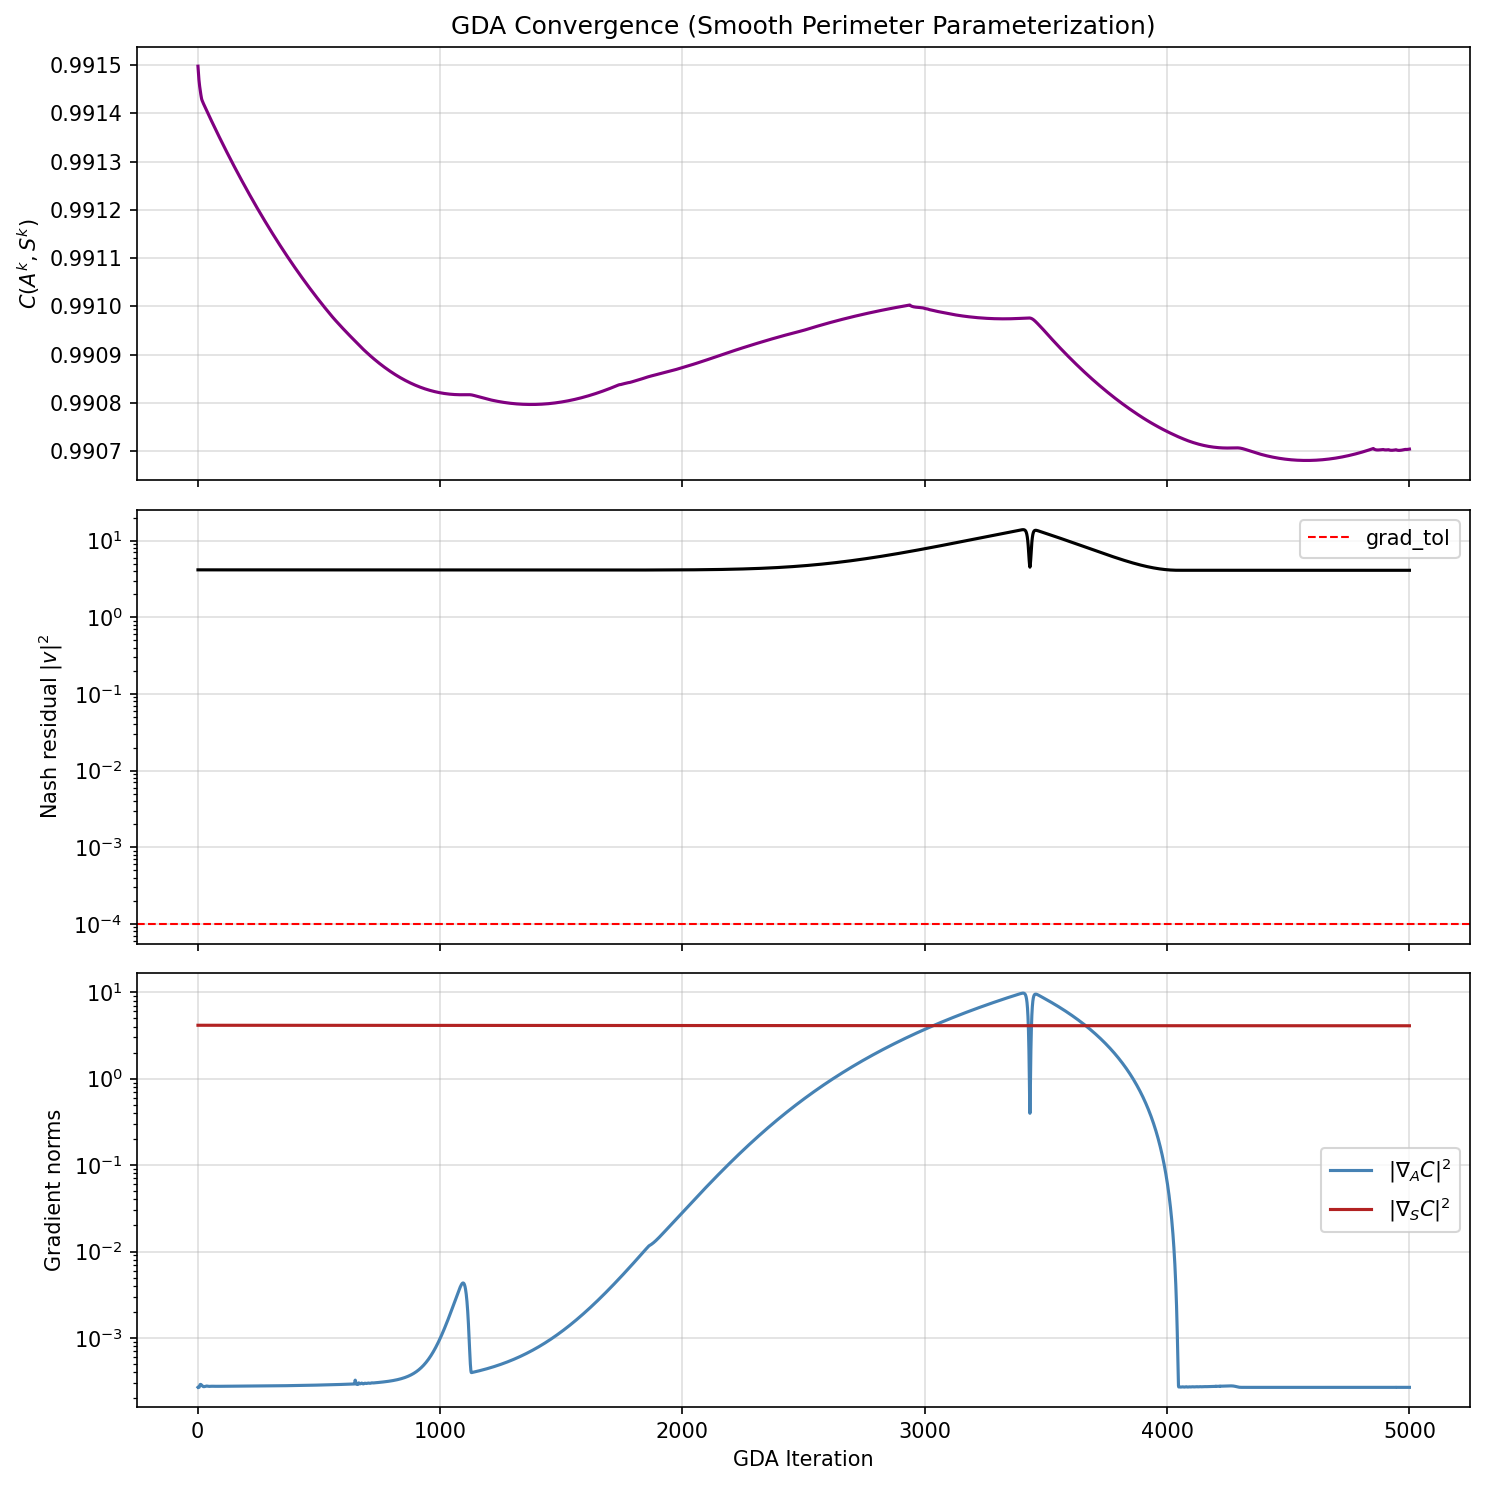

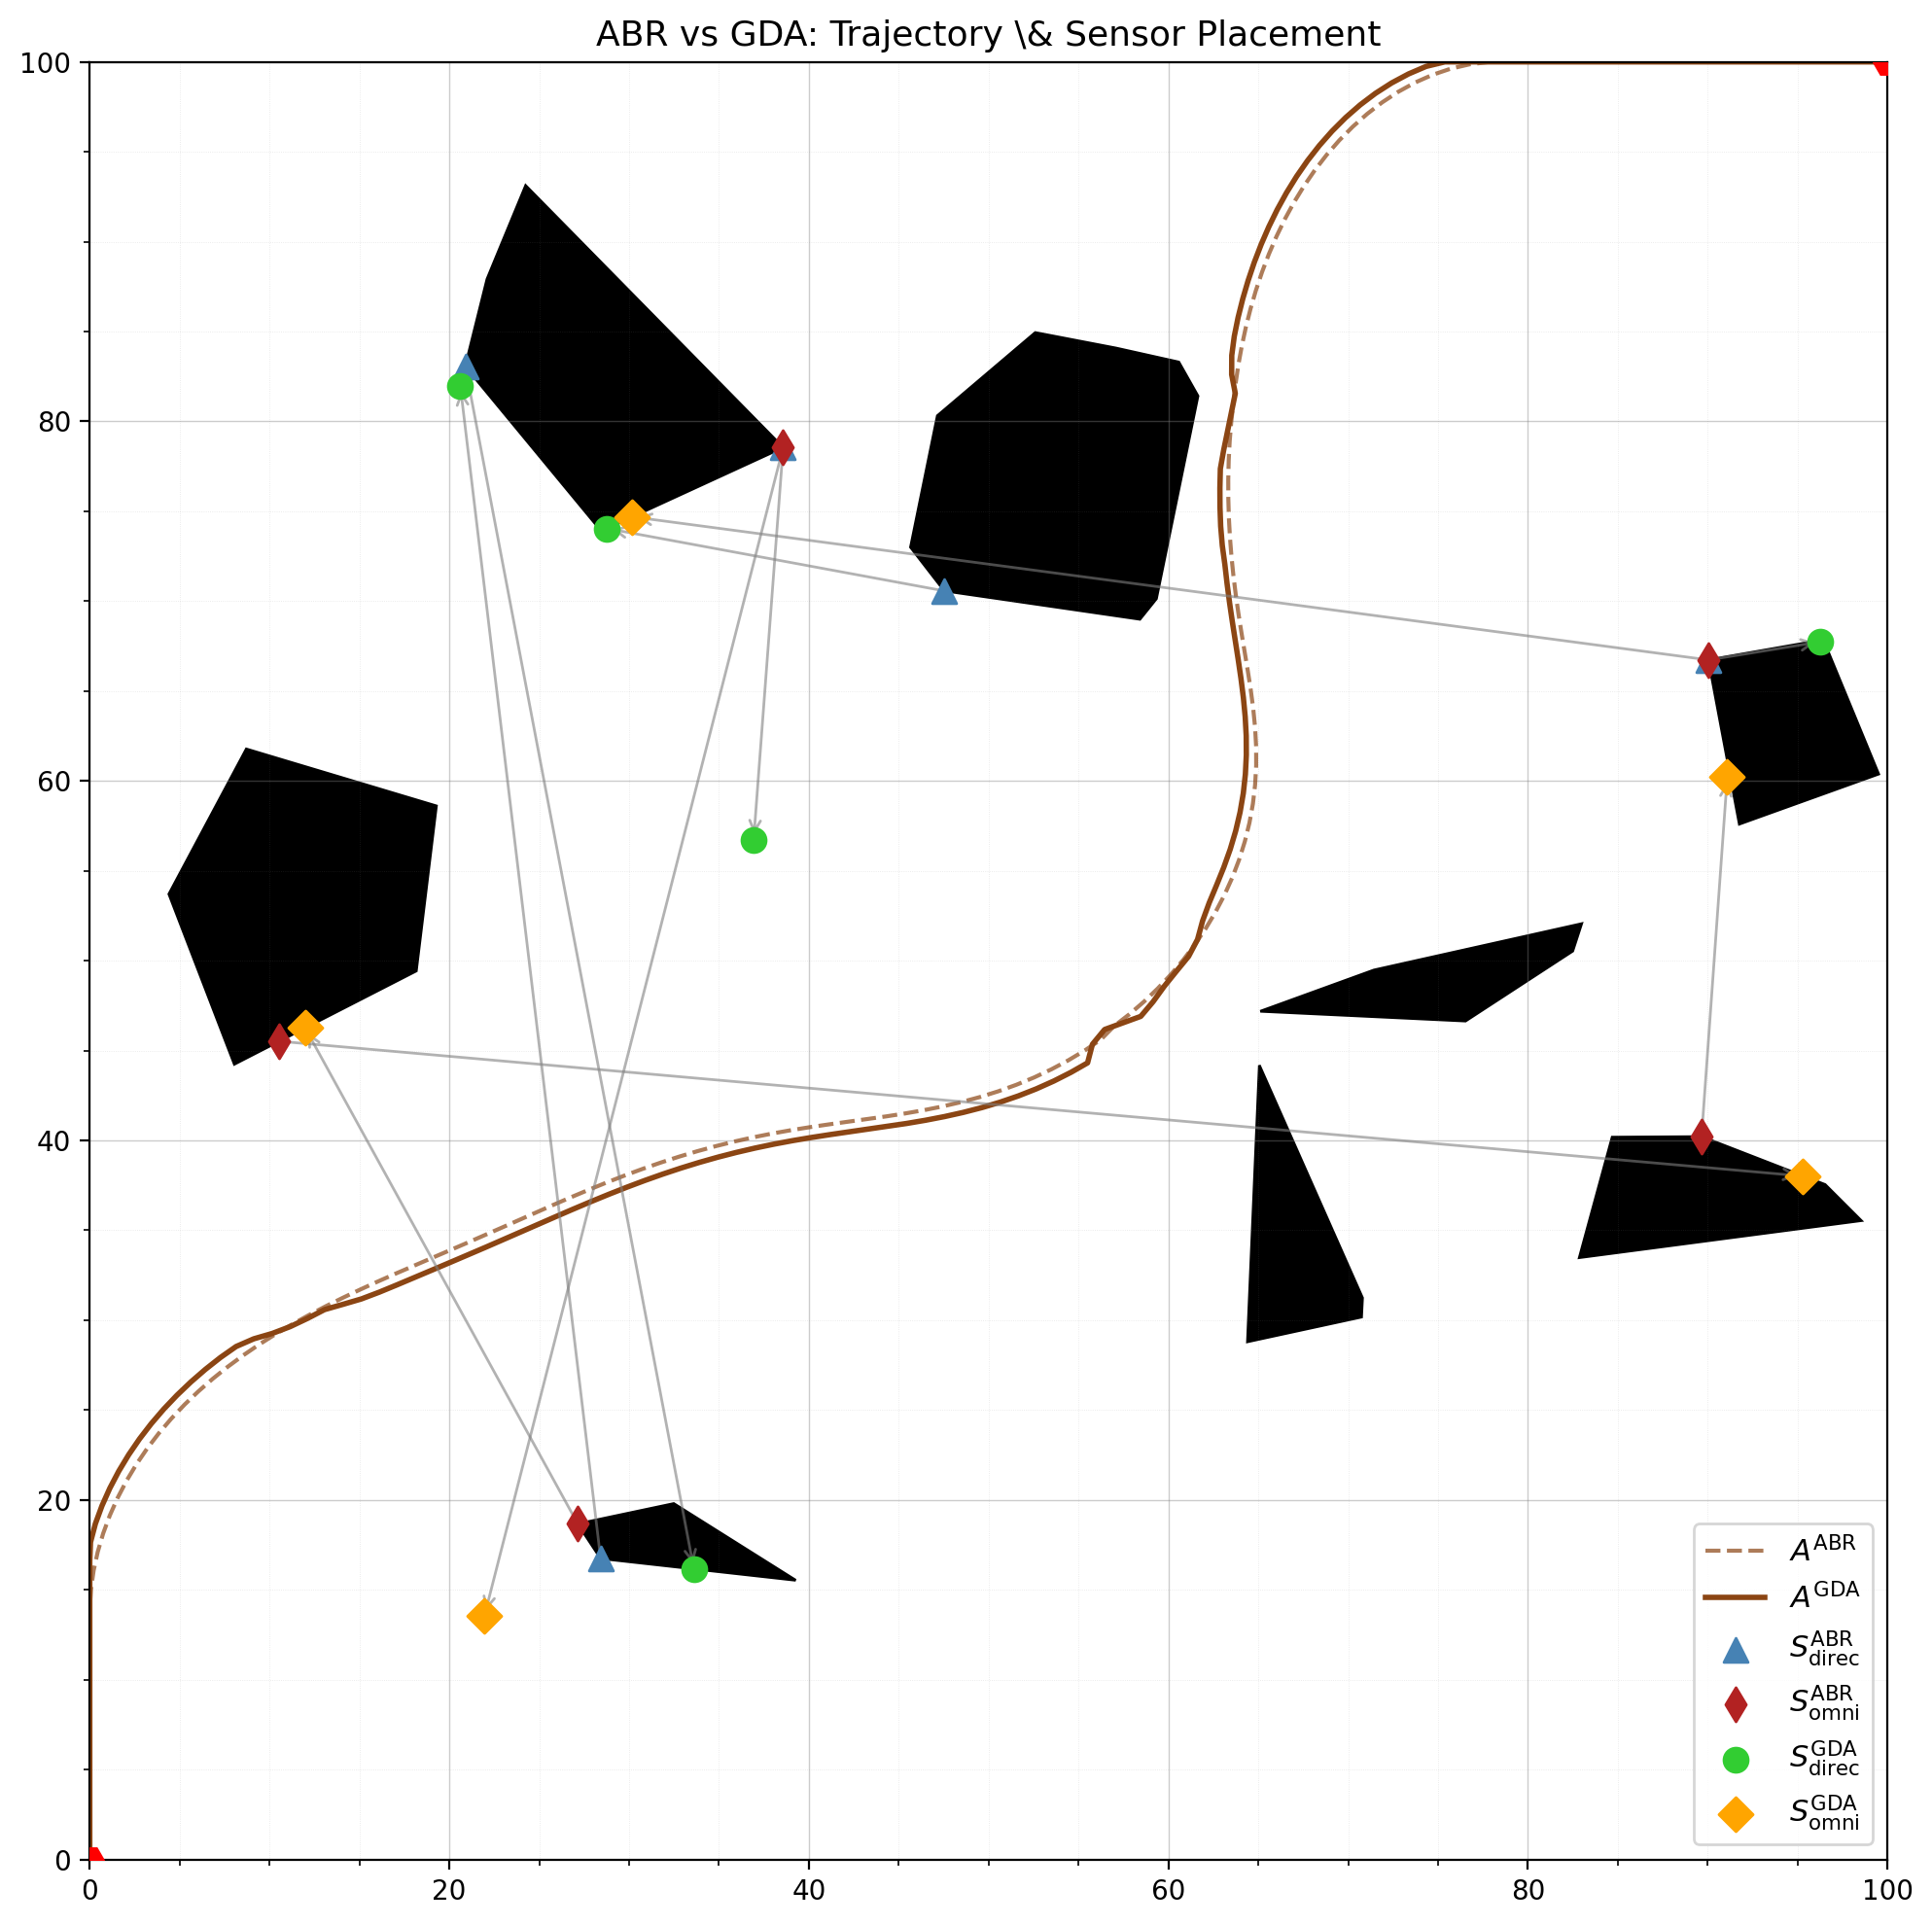

Machine spirit satisfied. GDA with smooth perimeter complete.


In [23]:
##############################################################################
# --- Smooth Perimeter Parameterization + Simultaneous GDA ---
#
# Key fix: instead of alpha_j on a SINGLE edge, each sensor j has a scalar
# s_j in [0,1] that parameterizes its position along the FULL building
# perimeter using sigmoid smoothing at corners for C1 continuity.
#
# Perimeter map for sensor j on building b_j:
#   - Compute cumulative arc lengths of all edges: [0, L0, L0+L1, ...]
#   - Total perimeter L_total
#   - Arc position: d = s_j * L_total
#   - For each edge i: use sigmoid to blend contribution
#     pos(s_j) = sum_i [ sigmoid_weight_i(d) * (p0_i + t_i * v_i) ]
#   where sigmoid_weight_i smoothly activates when d is near edge i
#
# This makes pos(s_j) differentiable everywhere — no gradient vanishing
# at edge endpoints.
##############################################################################

import casadi as ca
import numpy as np
from convex_map import mount_sensors_on_edges

# ------------------------------------------------------------------ #
#  Rebuild sensor->building assignment using same rng_seed as generate_map
# ------------------------------------------------------------------ #
sensors_info = mount_sensors_on_edges(
    num_sensors  = cam_dict['n'],
    buildings    = [map_in['st'][str(i)].tolist() for i in range(map_in['st']['n'])],
    rng_seed     = rng_seed + 1,   # same seed as generate_map
    outward_offset = 1e-3,
    balanced     = False
)
sensor_building_idx = [s['building'] for s in sensors_info]
print("Sensor -> Building assignments:", sensor_building_idx)

# ------------------------------------------------------------------ #
#  Build perimeter data for each building
#  perimeter_data[b] = list of (p0, v_e, L_e) for each edge, plus L_total
# ------------------------------------------------------------------ #
def build_perimeter_data(building_vertices):
    """
    Given (N_verts, 2) array of building vertices,
    returns dict with:
      edges     : list of (p0, p1) numpy arrays
      lengths   : list of edge lengths
      cumlen    : cumulative arc lengths [0, L0, L0+L1, ...]  length N_edges+1
      L_total   : total perimeter length
    """
    verts = np.array(building_vertices, dtype=float)
    N     = len(verts)
    edges, lengths, cumlen = [], [], [0.0]
    for i in range(N):
        p0 = verts[i]
        p1 = verts[(i + 1) % N]
        Le = float(np.linalg.norm(p1 - p0))
        edges.append((p0, p1))
        lengths.append(Le)
        cumlen.append(cumlen[-1] + Le)
    return {
        'edges'  : edges,
        'lengths': lengths,
        'cumlen' : np.array(cumlen, dtype=float),
        'L_total': cumlen[-1]
    }

perimeter_data = {}
for b in range(map_in['st']['n']):
    perimeter_data[b] = build_perimeter_data(map_in['st'][str(b)])

# ------------------------------------------------------------------ #
#  Compute initial s_j for each sensor from its current (x,y) position
# ------------------------------------------------------------------ #
def xy_to_s(xy, pdata):
    """
    Find the perimeter parameter s in [0,1] for point xy on building perimeter.
    Projects onto closest point on perimeter, returns arc_distance / L_total.
    """
    best_d2, best_arc = np.inf, 0.0
    for i, (p0, p1) in enumerate(pdata['edges']):
        v   = p1 - p0
        L2  = float(v @ v)
        if L2 < 1e-16:
            continue
        t   = float((xy - p0) @ v / L2)
        t   = np.clip(t, 0.0, 1.0)
        proj = p0 + t * v
        d2  = float(np.sum((xy - proj)**2))
        if d2 < best_d2:
            best_d2  = d2
            best_arc = pdata['cumlen'][i] + t * pdata['lengths'][i]
    return best_arc / pdata['L_total']

# Initial s_j values from current sensor positions
cam_x_all = np.hstack([cam_dict['directional']['x'], cam_dict['omnidirectional']['x']])
cam_y_all = np.hstack([cam_dict['directional']['y'], cam_dict['omnidirectional']['y']])

s_init = np.zeros(cam_dict['n'])
for j in range(cam_dict['n']):
    b   = sensor_building_idx[j]
    xy  = np.array([cam_x_all[j], cam_y_all[j]])
    s_init[j] = xy_to_s(xy, perimeter_data[b])

print("Initial s_j values:", np.round(s_init, 4))

# ------------------------------------------------------------------ #
#  Symbolic perimeter map: s_j (scalar MX) -> (x, y) on building b
#  Uses sigmoid blending for C1 smoothness at corners
# ------------------------------------------------------------------ #
def perimeter_pos_sym(s_sym, pdata, sharpness=1):
    """
    Maps scalar CasADi symbol s in [0,1] to (x, y) on building perimeter.
    Uses sigmoid blending: each edge i contributes when d is in [cumlen[i], cumlen[i+1]].

    sharpness: controls how sharp the sigmoid transitions are at corners.
               Higher = sharper (closer to hard switching), lower = smoother.
    """
    L_total = pdata['L_total']
    d       = s_sym * L_total   # arc distance

    x_out = 0.0
    y_out = 0.0

    n_edges = len(pdata['edges'])
    for i, (p0, p1) in enumerate(pdata['edges']):
        v  = p1 - p0
        Le = pdata['lengths'][i]
        c0 = pdata['cumlen'][i]      # start arc of this edge
        c1 = pdata['cumlen'][i + 1]  # end arc of this edge

        # Sigmoid gates: activate when d is between c0 and c1
        gate_on  = 1 / (1 + ca.exp(-sharpness * (d - c0)))   # turns on  at c0
        gate_off = 1 / (1 + ca.exp(-sharpness * (d - c1)))   # turns off at c1
        weight   = gate_on - gate_off                          # ~1 inside edge, ~0 outside

        # Local parameter t in [0,1] along this edge
        t = ca.fmax((d - c0) / (Le + 1e-9), 0.0)
        t = ca.fmin(t, 1.0)

        pos_x = p0[0] + t * v[0]
        pos_y = p0[1] + t * v[1]

        x_out = x_out + weight * pos_x
        y_out = y_out + weight * pos_y

    return x_out, y_out


# ------------------------------------------------------------------ #
#  GDA with smooth perimeter parameterization
# ------------------------------------------------------------------ #
def optimize_simultaneous_gda(A_init_np, s_init_np,
                               N=None,
                               max_iters=2000,
                               lr_A=1e-4,
                               lr_S=1e-3,
                               beta1=0.9, beta2=0.999, adam_eps=1e-8,
                               grad_tol=1e-4,
                               obs_penalty_weight=10.0,
                               gamma_obs=500,
                               safety_margin=2.0):
    """
    Simultaneous GDA with smooth full-perimeter sensor parameterization.

    Parameters
    ----------
    A_init_np  : (3, N+1) numpy array -- warm start attacker
    s_init_np  : (M,)     numpy array -- initial perimeter params s_j in [0,1]
    """
    if N is None:
        N = N_attk

    start_time = path[0][2]
    end_time   = path[-1][2]
    M_sensors  = cam_dict['n']

    # ---------------------------------------------------------------- #
    #  Build symbolic gradient functions ONCE
    # ---------------------------------------------------------------- #
    print('Building symbolic gradient functions with smooth perimeter map...')

    x_sym   = ca.MX.sym('x',   N + 1)
    y_sym   = ca.MX.sym('y',   N + 1)
    T_sym   = ca.MX.sym('T')
    s_sym   = ca.MX.sym('s',   M_sensors)   # perimeter params

    dt_sym  = T_sym / N

    # Sensor positions from smooth perimeter map
    Sx_s, Sy_s = [], []
    for j in range(M_sensors):
        b    = sensor_building_idx[j]
        px, py = perimeter_pos_sym(s_sym[j], perimeter_data[b])
        Sx_s.append(px)
        Sy_s.append(py)
    S_sym_mat = ca.vertcat(ca.hcat(Sx_s), ca.hcat(Sy_s))  # (2, M)

    # Camera objects for pan-angle timing (frozen at init positions)
    cam_objs_gda = []
    for i in range(cam_dict['n_direc']):
        cam_objs_gda.append(Camera(i, cam_dict,
                                   float(cam_x_all[i]),
                                   float(cam_y_all[i])))

    # Detection cost C(A, S) symbolic
    t_nodes_sym = [start_time + i * dt_sym for i in range(N + 1)]
    log_sum_s   = 0
    for i in range(N + 1):
        xi = x_sym[i]; yi = y_sym[i]; ti = t_nodes_sym[i]
        k_prod = 1.0
        for cam_i in range(M_sensors):
            dx_i      = xi - S_sym_mat[0, cam_i]
            dy_i      = yi - S_sym_mat[1, cam_i]
            dist_sq   = dx_i**2 + dy_i**2
            dist_min  = ca.fmax(dist_sq, 1e-4)
            dist_safe = ca.sqrt(dist_min)
            if cam_i < cam_dict['n_direc']:
                cam_obj = cam_objs_gda[cam_i]
                phi     = cam_obj.get_ctr_theta_t(ti)
                theta   = cam_obj.fov_ang
                cos_a   = (dx_i*ca.cos(phi) + dy_i*ca.sin(phi)) / dist_safe
                vis     = 1 / (1 + ca.exp(-c_param*(cos_a - ca.cos(theta/2))))
                obs_r   = 1 / (1 + alpha_direc*dist_min)
            else:
                vis   = 1.0
                obs_r = 1 / (1 + alpha_omni*dist_min)
            k_j     = vis * obs_r
            k_prod *= (1 - k_j)
        k_total    = 1 - k_prod
        log_sum_s += -ca.log(1.0 - k_total + 1e-9)

    time_penalty_s = 0.02 * T_sym
    C_sym = log_sum_s - time_penalty_s

    # Obstacle penalty for attacker
    obs_penalty_s = 0
    for i in range(N + 1):
        p_k = ca.vertcat(x_sym[i], y_sym[i])
        for obs_data in obstacle_constraints:
            A_obs   = obs_data['A']
            b_obs   = obs_data['b']
            h_vec   = ca.mtimes(A_obs, p_k) - b_obs
            n_edges = A_obs.shape[0]
            max_h   = h_vec[0]
            for idx in range(1, n_edges):
                max_h = ca.fmax(max_h, h_vec[idx])
            lse     = max_h + (1.0/gamma_obs)*ca.log(
                ca.sum(ca.exp(gamma_obs*(h_vec - max_h))))
            lse_deb = lse - (ca.log(n_edges)/gamma_obs)
            violation = ca.fmax(safety_margin - lse_deb, 0)
            obs_penalty_s += violation**2

    C_aug_sym = C_sym + obs_penalty_weight * obs_penalty_s

    # Gradients
    w_A_sym  = ca.vertcat(x_sym, y_sym, T_sym)
    grad_A_s = ca.gradient(C_aug_sym, w_A_sym)
    grad_D_s = ca.gradient(C_sym, s_sym)
    nash_res_s = ca.dot(grad_A_s, grad_A_s) + ca.dot(grad_D_s, grad_D_s)

    inputs      = [x_sym, y_sym, T_sym, s_sym]
    input_names = ['x', 'y', 'T', 's']
    fn_C    = ca.Function('C',    inputs, [C_sym],      input_names, ['C'])
    fn_gA   = ca.Function('gA',   inputs, [grad_A_s],   input_names, ['gA'])
    fn_gD   = ca.Function('gD',   inputs, [grad_D_s],   input_names, ['gD'])
    fn_nash = ca.Function('nash', inputs, [nash_res_s], input_names, ['nash'])
    print('Done. Starting GDA iterations...')

    # ---------------------------------------------------------------- #
    #  Initialize
    # ---------------------------------------------------------------- #
    x_k   = A_init_np[0, :].copy()
    y_k   = A_init_np[1, :].copy()
    T_k   = float(A_init_np[2, -1] - A_init_np[2, 0])
    s_k   = s_init_np.copy()

    # Adam state
    n_A   = 2*(N+1) + 1
    mA, vA = np.zeros(n_A), np.zeros(n_A)
    mD, vD = np.zeros(M_sensors), np.zeros(M_sensors)

    history = {'C': [], 'nash_residual': [], 'grad_A_norm': [], 'grad_D_norm': []}

    # ---------------------------------------------------------------- #
    #  GDA loop
    # ---------------------------------------------------------------- #
    for it in range(1, max_iters + 1):
        gA_val = np.array(fn_gA(x_k, y_k, T_k, s_k)).flatten()
        gD_val = np.array(fn_gD(x_k, y_k, T_k, s_k)).flatten()
        C_val  = float(fn_C(x_k, y_k, T_k, s_k))
        nr_val = float(fn_nash(x_k, y_k, T_k, s_k))

        gA_norm = float(np.dot(gA_val, gA_val))
        gD_norm = float(np.dot(gD_val, gD_val))

        history['C'].append(C_val)
        history['nash_residual'].append(nr_val)
        history['grad_A_norm'].append(gA_norm)
        history['grad_D_norm'].append(gD_norm)

        if gA_norm + gD_norm < grad_tol:
            print(f'  Converged at iter {it}: ||gA||^2+||gD||^2 = {gA_norm+gD_norm:.4e}')
            break

        if it % 100 == 0:
            print(f'  Iter {it:4d} | C={C_val:.4f} | Nash={nr_val:.4e} '
                  f'| ||gA||^2={gA_norm:.4e} | ||gD||^2={gD_norm:.4e}')

        # Adam — attacker (descent)
        mA = beta1*mA + (1-beta1)*gA_val
        vA = beta2*vA + (1-beta2)*gA_val**2
        mA_hat = mA / (1 - beta1**it)
        vA_hat = vA / (1 - beta2**it)
        step_A = lr_A * mA_hat / (np.sqrt(vA_hat) + adam_eps)

        x_new = x_k - step_A[:N+1]
        y_new = y_k - step_A[N+1:2*(N+1)]
        T_new = T_k - step_A[-1]

        # Adam — defender (ascent)
        mD = beta1*mD + (1-beta1)*gD_val
        vD = beta2*vD + (1-beta2)*gD_val**2
        mD_hat = mD / (1 - beta1**it)
        vD_hat = vD / (1 - beta2**it)
        step_D = lr_S * mD_hat / (np.sqrt(vD_hat) + adam_eps)
        s_new  = s_k + step_D

        # Projection — attacker
        x_new[0]  = x0[0];  y_new[0]  = x0[1]
        x_new[-1] = xf[0];  y_new[-1] = xf[1]
        x_new = np.clip(x_new, map_size[0], map_size[1])
        y_new = np.clip(y_new, map_size[2], map_size[3])
        dt_cur    = T_new / N
        vmax_step = vmax * dt_cur
        for k in range(N):
            diff   = np.array([x_new[k+1]-x_new[k], y_new[k+1]-y_new[k]])
            d_norm = np.linalg.norm(diff)
            if d_norm > vmax_step:
                scale       = vmax_step / d_norm
                x_new[k+1] = x_new[k] + diff[0]*scale
                y_new[k+1] = y_new[k] + diff[1]*scale
        T_new = float(np.clip(T_new, 1e-3, end_time*1.5))

        # Projection — defender: wrap s to [0, 1] (perimeter is periodic)
        s_new = s_new % 1.0

        x_k, y_k, T_k, s_k = x_new, y_new, T_new, s_new

    else:
        print(f'  Max iters ({max_iters}) reached. Nash residual = {nr_val:.4e}')

    # ---------------------------------------------------------------- #
    #  Build output
    # ---------------------------------------------------------------- #
    t_opt = np.linspace(start_time, start_time + T_k, N+1)
    A_gda = np.vstack((x_k, y_k, t_opt))

    # Recover sensor (x,y) from s_k via numeric evaluation
    s_eval = ca.MX.sym('s_e', M_sensors)
    Sx_e, Sy_e = [], []
    for j in range(M_sensors):
        b = sensor_building_idx[j]
        px, py = perimeter_pos_sym(s_eval[j], perimeter_data[b])
        Sx_e.append(px); Sy_e.append(py)
    S_expr  = ca.vertcat(ca.hcat(Sx_e), ca.hcat(Sy_e))
    fn_Spos = ca.Function('Spos', [s_eval], [S_expr])
    S_gda   = np.array(fn_Spos(s_k))   # (2, M)

    C_gda = eval_C_numeric(A_gda, S_gda)
    print(f'  C(A_gda, S_gda)   = {C_gda:.6f}')
    print(f'  P_D at GDA result = {1 - np.exp(-C_gda):.6f}')

    return A_gda, S_gda, s_k, C_gda, history


##############################################################################
# --- Run GDA ---
##############################################################################
print('=== ABR result (for reference) ===')
C_abr = eval_C_numeric(A_star, S_star)
print(f'  C(A_abr, S_abr)   = {C_abr:.6f}')
print(f'  P_D at ABR result = {1 - np.exp(-C_abr):.6f}')
print()

A_gda, S_gda, s_gda, C_gda_val, gda_history = optimize_simultaneous_gda(
    A_init_np  = A_star,
    s_init_np  = s_init,
    N          = N_attk,
    max_iters  = 5000,
    lr_A       = 1e-4,
    lr_S       = 1e-7,
    grad_tol   = 1e-4,
    obs_penalty_weight = 10.0,
)

# Also expose alpha_gda for saddle point cell compatibility
alpha_gda = s_gda   # rename for downstream cells

##############################################################################
# --- Nash Equilibrium Verification ---
##############################################################################
print()
print('=== Nash Equilibrium Verification ===')
C_abr_val  = eval_C_numeric(A_star, S_star)
C_gda_val2 = eval_C_numeric(A_gda,  S_gda)

C_Aabr_Sgda = eval_C_numeric(A_star, S_gda)
print(f'  C(A_abr, S_gda) = {C_Aabr_Sgda:.6f}  <- attacker deviation')
print(f'  C(A_gda, S_gda) = {C_gda_val2:.6f}  <- GDA payoff')
print(f'  Attacker gain:    {C_Aabr_Sgda - C_gda_val2:.4e}  (>= 0: A_gda better for attacker)')

C_Agda_Sabr = eval_C_numeric(A_gda, S_star)
print(f'  C(A_gda, S_abr) = {C_Agda_Sabr:.6f}  <- defender deviation')
print(f'  C(A_gda, S_gda) = {C_gda_val2:.6f}  <- GDA payoff')
print(f'  Defender gain:    {C_gda_val2 - C_Agda_Sabr:.4e}  (>= 0: S_gda better for defender)')

print()
print(f'  ABR:  C = {C_abr_val:.6f}  |  P_D = {1 - np.exp(-C_abr_val):.6f}')
print(f'  GDA:  C = {C_gda_val2:.6f}  |  P_D = {1 - np.exp(-C_gda_val2):.6f}')

##############################################################################
# --- Convergence plot ---
##############################################################################
fig_conv, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=150, sharex=True)
iters = np.arange(1, len(gda_history['C']) + 1)

axes[0].plot(iters, gda_history['C'], '-', color='purple', lw=1.5)
axes[0].set_ylabel(r'$C(A^k, S^k)$')
axes[0].set_title('GDA Convergence (Smooth Perimeter Parameterization)')
axes[0].grid(alpha=0.4)

axes[1].semilogy(iters, gda_history['nash_residual'], '-k', lw=1.5)
axes[1].axhline(y=grad_tol if 'grad_tol' in dir() else 1e-4,
                color='red', linestyle='--', lw=1.0, label='grad_tol')
axes[1].set_ylabel(r'Nash residual $\|v\|^2$')
axes[1].legend(); axes[1].grid(alpha=0.4)

axes[2].semilogy(iters, gda_history['grad_A_norm'],
                 '-', color='steelblue', lw=1.5, label=r'$\|\nabla_A C\|^2$')
axes[2].semilogy(iters, gda_history['grad_D_norm'],
                 '-', color='firebrick', lw=1.5, label=r'$\|\nabla_S C\|^2$')
axes[2].set_ylabel('Gradient norms'); axes[2].set_xlabel('GDA Iteration')
axes[2].legend(); axes[2].grid(alpha=0.4)
plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_GDA_convergence.png',
            dpi=150, bbox_inches='tight')
plt.show()

##############################################################################
# --- Map plot ---
##############################################################################
fig_gda, ax_gda = plt.subplots(figsize=(10, 10), dpi=200)
st_  = map_in['st']; sz = np.array(st_['size'], dtype=float)
xmn, xmx, ymn, ymx = sz
for i in range(st_['n']):
    ax_gda.add_patch(PolyPatch(np.array(st_[str(i)], dtype=float),
                                closed=True, facecolor='black', edgecolor='black'))
ax_gda.plot(A_star[0,:], A_star[1,:], '--',
             color='saddlebrown', lw=1.5, alpha=0.7, label=r'$A^{\rm ABR}$')
ax_gda.plot(A_gda[0,:],  A_gda[1,:],  '-',
             color='saddlebrown', lw=2.0, label=r'$A^{\rm GDA}$')
ax_gda.scatter(S_star[0,:num_direc_sensor], S_star[1,:num_direc_sensor],
                s=80, marker='^', color='steelblue', zorder=5, label=r'$S^{\rm ABR}_{\rm direc}$')
ax_gda.scatter(S_star[0,num_direc_sensor:], S_star[1,num_direc_sensor:],
                s=80, marker='d', color='firebrick', zorder=5, label=r'$S^{\rm ABR}_{\rm omni}$')
ax_gda.scatter(S_gda[0,:num_direc_sensor],  S_gda[1,:num_direc_sensor],
                s=80, marker='o', color='limegreen', zorder=6, label=r'$S^{\rm GDA}_{\rm direc}$')
ax_gda.scatter(S_gda[0,num_direc_sensor:],  S_gda[1,num_direc_sensor:],
                s=80, marker='D', color='orange',    zorder=6, label=r'$S^{\rm GDA}_{\rm omni}$')
for j in range(cam_dict['n']):
    ax_gda.annotate('', xy=(S_gda[0,j], S_gda[1,j]),
                    xytext=(S_star[0,j], S_star[1,j]),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.0, alpha=0.6))
ax_gda.plot(x0[0], x0[1], 'H', c='red', markersize=10, zorder=10)
ax_gda.plot(xf[0], xf[1], 'H', c='red', markersize=10, zorder=10)
ax_gda.set_xlim(xmn, xmx); ax_gda.set_ylim(ymn, ymx)
ax_gda.set_aspect('equal'); ax_gda.minorticks_on()
ax_gda.grid(which='major', linestyle='-',  lw=0.5, color='gray', alpha=0.4)
ax_gda.grid(which='minor', linestyle=':',  lw=0.3, color='gray', alpha=0.2)
ax_gda.legend(loc='lower right', fontsize=11)
ax_gda.set_title(r'ABR vs GDA: Trajectory \& Sensor Placement', fontsize=13)
plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_GDA_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Machine spirit satisfied. GDA with smooth perimeter complete.')


In [24]:
# Check what sensors_info looks like
for j, s in enumerate(sensors_info):
    print(f"Sensor {j}: building={s['building']}, pos={s['pos']}")

print(rng_seed)

Sensor 0: building=4, pos=(46.485932974121894, 71.92604170057447)
Sensor 1: building=5, pos=(33.64114718313671, 16.15681783544767)
Sensor 2: building=2, pos=(28.97295361916307, 74.13529318821679)
Sensor 3: building=2, pos=(21.611280417432955, 85.97166456153376)
Sensor 4: building=7, pos=(96.38549418852136, 67.84396374671464)
Sensor 5: building=6, pos=(95.03957882866482, 38.12448724035768)
Sensor 6: building=5, pos=(27.85913844856292, 17.585618415376494)
Sensor 7: building=1, pos=(12.044586900816574, 46.28914024742598)
Sensor 8: building=7, pos=(91.22004669671817, 60.464009628558955)
Sensor 9: building=2, pos=(30.363107319323323, 74.774314760229)
4134


In [19]:
afafsfasf

NameError: name 'afafsfasf' is not defined

In [ ]:
##############################################################################
# --- 3D Saddle Point Visualization ---
# Sweeps attacker and defender strategies along the line connecting
# ABR result -> GDA result (and beyond), evaluating C(A(t), S(s)) at each
# (t, s) grid point.
#
# Axes:
#   t (x): attacker interpolation  A(t)     = (1-t)*A_abr     + t*A_gda
#   s (y): defender interpolation  alpha(s) = (1-s)*alpha_abr + s*alpha_gda
#   z:     C(A(t), S(s))
#
# At the GDA solution (t=1, s=1):
#   - Moving in t (attacker deviates) -> C should increase (attacker can't improve)
#   - Moving in s (defender deviates) -> C should decrease (defender can't improve)
#   That's the saddle shape.
##############################################################################

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# ------------------------------------------------------------------ #
#  Grid setup
# ------------------------------------------------------------------ #
n_grid  = 30          # resolution (increase for smoother surface, slower)
t_range = np.linspace(0.0, 2.0, n_grid)   # attacker axis: 0=ABR, 1=GDA, 2=beyond
s_range = np.linspace(0.0, 2.0, n_grid)   # defender axis: 0=ABR, 1=GDA, 2=beyond

# ------------------------------------------------------------------ #
#  Reference points
# ------------------------------------------------------------------ #
A_abr_ref     = A_star.copy()        # (3, N+1) ABR attacker trajectory
alpha_abr_ref = alpha_star.copy()    # (M,)     ABR defender alpha

A_gda_ref     = A_gda.copy()         # (3, N+1) GDA attacker trajectory
alpha_gda_ref = alpha_gda.copy()     # (M,)     GDA defender alpha

# ------------------------------------------------------------------ #
#  Evaluate C on the (t, s) grid
# ------------------------------------------------------------------ #
print(f'Evaluating C on {n_grid}x{n_grid} grid...')
C_grid = np.zeros((n_grid, n_grid))

for i, t in enumerate(t_range):
    # Interpolate attacker trajectory
    A_t = (1 - t) * A_abr_ref + t * A_gda_ref   # (3, N+1)

    for j, s in enumerate(s_range):
        # Interpolate defender alpha
        alpha_s = (1 - s) * alpha_abr_ref + s * alpha_gda_ref   # (M,)

        # Defender sensor positions from alpha_s
        S_s = np.column_stack([
            building_edge_vec[k] + alpha_s[k] * building_vector_vec[k]
            for k in range(cam_dict['n'])
        ])   # (2, M)

        C_grid[i, j] = eval_C_numeric(A_t, S_s)

    if (i + 1) % 5 == 0:
        print(f'  Row {i+1}/{n_grid} done')

print('Grid evaluation complete.')

# ------------------------------------------------------------------ #
#  3D surface plot
# ------------------------------------------------------------------ #
T_mesh, S_mesh = np.meshgrid(t_range, s_range, indexing='ij')

fig_3d = plt.figure(figsize=(12, 8), dpi=150)
ax3d   = fig_3d.add_subplot(111, projection='3d')

surf = ax3d.plot_surface(
    T_mesh, S_mesh, C_grid,
    cmap=cm.RdBu_r,
    alpha=0.85,
    linewidth=0,
    antialiased=True
)

# Mark ABR point (t=0, s=0)
C_abr_pt = C_grid[0, 0]
ax3d.scatter([0], [0], [C_abr_pt],
             color='steelblue', s=80, zorder=10,
             label=r'ABR $(t=0, s=0)$')

# Mark GDA point (t=1, s=1) -- find nearest grid index
t_idx = np.argmin(np.abs(t_range - 1.0))
s_idx = np.argmin(np.abs(s_range - 1.0))
C_gda_pt = C_grid[t_idx, s_idx]
ax3d.scatter([1], [1], [C_gda_pt],
             color='limegreen', s=80, zorder=10,
             label=r'GDA $(t=1, s=1)$')

# Draw saddle cross-sections through GDA point
# Attacker slice: fix s=1, sweep t
ax3d.plot(t_range, np.ones(n_grid), C_grid[:, s_idx],
          '-', color='firebrick', lw=2.0, label=r'Attacker slice ($s=1$ fixed)')
# Defender slice: fix t=1, sweep s
ax3d.plot(np.ones(n_grid), s_range, C_grid[t_idx, :],
          '-', color='orange', lw=2.0, label=r'Defender slice ($t=1$ fixed)')

# Colorbar
fig_3d.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10, label=r'$C(A(t), S(s))$')

ax3d.set_xlabel(r'Attacker interpolation $t$' + '\n' + r'($t=0$: ABR, $t=1$: GDA)',
                labelpad=10)
ax3d.set_ylabel(r'Defender interpolation $s$' + '\n' + r'($s=0$: ABR, $s=1$: GDA)',
                labelpad=10)
ax3d.set_zlabel(r'$C(A(t), S(s))$', labelpad=10)
ax3d.set_title(r'Saddle Point Visualization: $C(A(t), S(s))$', fontsize=13)
ax3d.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_saddle_point_3d.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------ #
#  2D cross-section plot (cleaner view of saddle shape)
# ------------------------------------------------------------------ #
fig_2d, (ax_att, ax_def) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Attacker slice: fix s=1 (defender at GDA), sweep attacker t
ax_att.plot(t_range, C_grid[:, s_idx], '-', color='firebrick', lw=2.0)
ax_att.axvline(x=1.0, color='limegreen', linestyle='--', lw=1.5, label='GDA point')
ax_att.axvline(x=0.0, color='steelblue', linestyle='--', lw=1.5, label='ABR point')
ax_att.set_xlabel(r'Attacker interpolation $t$  ($t=0$: ABR, $t=1$: GDA)')
ax_att.set_ylabel(r'$C(A(t), S_{\rm GDA})$')
ax_att.set_title(r'Attacker deviation (defender fixed at GDA $S^*$)')
ax_att.legend()
ax_att.grid(alpha=0.4)

# Defender slice: fix t=1 (attacker at GDA), sweep defender s
ax_def.plot(s_range, C_grid[t_idx, :], '-', color='orange', lw=2.0)
ax_def.axvline(x=1.0, color='limegreen', linestyle='--', lw=1.5, label='GDA point')
ax_def.axvline(x=0.0, color='steelblue', linestyle='--', lw=1.5, label='ABR point')
ax_def.set_xlabel(r'Defender interpolation $s$  ($s=0$: ABR, $s=1$: GDA)')
ax_def.set_ylabel(r'$C(A_{\rm GDA}, S(s))$')
ax_def.set_title(r'Defender deviation (attacker fixed at GDA $A^*$)')
ax_def.legend()
ax_def.grid(alpha=0.4)

plt.suptitle(r'Saddle Point Cross-Sections at GDA Solution $(t=1, s=1)$', fontsize=13)
plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_saddle_point_2d.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Saddle point visualization complete.')
print()
print('=== Saddle Point Check ===')
print(f'  C at GDA (t=1, s=1):          {C_gda_pt:.6f}')
print(f'  C at ABR (t=0, s=0):          {C_abr_pt:.6f}')
print(f'  Min along attacker slice:     {np.min(C_grid[:, s_idx]):.6f}  (should be at t=1)')
print(f'  Max along defender slice:     {np.max(C_grid[t_idx, :]):.6f}  (should be at s=1)')
t_min_idx = np.argmin(C_grid[:, s_idx])
s_max_idx = np.argmax(C_grid[t_idx, :])
print(f'  Attacker min at t =           {t_range[t_min_idx]:.3f}  (ideal: 1.0)')
print(f'  Defender max at s =           {s_range[s_max_idx]:.3f}  (ideal: 1.0)')


Evaluating C on 30x30 grid...
  Row 5/30 done
  Row 10/30 done


In [ ]:
# -------------------------------------------------------
# Attacker best-response (ABR):
#   A_star   = attacker's best response (from last optimize_attacker call)
#   S_init   = INITIAL defender placement (the baseline)
# -------------------------------------------------------
# J_A: what the attacker achieves against the initial defender
log_sum_abr_A = eval_C_numeric(A_star, S_init)
J_A_abr = 1.0 - np.exp(-log_sum_abr_A)
print(f"J_A (Attacker BR vs S_init): {J_A_abr:.6f}")

# J_D: what the defender suffers when attacker plays BR against initial S
log_sum_abr_D = eval_C_numeric(A_star, S_init)  # same game value (zero-sum)
J_D_abr = 1.0 - np.exp(-log_sum_abr_D)
print(f"J_D (Attacker BR vs S_init): {J_D_abr:.6f}")

# Save sol_a for attacker BR
sol_a_abr = sol_a   # the CasADi solution object from optimize_attacker
A_star_abr = A_star.copy()  # (3, N_attk+1) numpy array

# -------------------------------------------------------
# Defender best-response (DBR):
#   S_star   = defender's best response (from last optimize_defender call)
#   A_initial = INITIAL attacker path (from STP-RRT*)
# -------------------------------------------------------
# J_D: what the defender achieves against the initial attacker
log_sum_dbr_D = eval_C_numeric(A_initial, S_star)
J_D_dbr = 1.0 - np.exp(-log_sum_dbr_D)
print(f"J_D (Defender BR vs A_init): {J_D_dbr:.6f}")

# J_A: what the attacker suffers when defender plays BR against initial A
log_sum_dbr_A = eval_C_numeric(A_initial, S_star)  # same game value
J_A_dbr = 1.0 - np.exp(-log_sum_dbr_A)
print(f"J_A (Defender BR vs A_init): {J_A_dbr:.6f}")

# Save sol_d for defender BR
sol_d_abr = sol_d   # the CasADi solution object from optimize_defender
S_star_dbr = S_star.copy()  # (2, M) numpy array
alpha_star_dbr = alpha_star.copy()  # (M,) numpy array

# J_A: what attacker gets at (A_star, S_star) — the paired strategies
log_A = eval_C_numeric(A_star, S_star)
J_A   = 1.0 - np.exp(-log_A)   # attacker wants this HIGH

# J_D: what defender gets at (A_star, S_star) — same pair, same value
# (zero-sum: J_D = J_A by definition in this game)
J_D   = J_A
print(f"Payoff at current strategies: J = {J_A:.6f}")

J_A (Attacker BR vs S_init): 0.783087
J_D (Attacker BR vs S_init): 0.783087
J_D (Defender BR vs A_init): 0.180524
J_A (Defender BR vs A_init): 0.180524
Payoff at current strategies: J = 0.805552


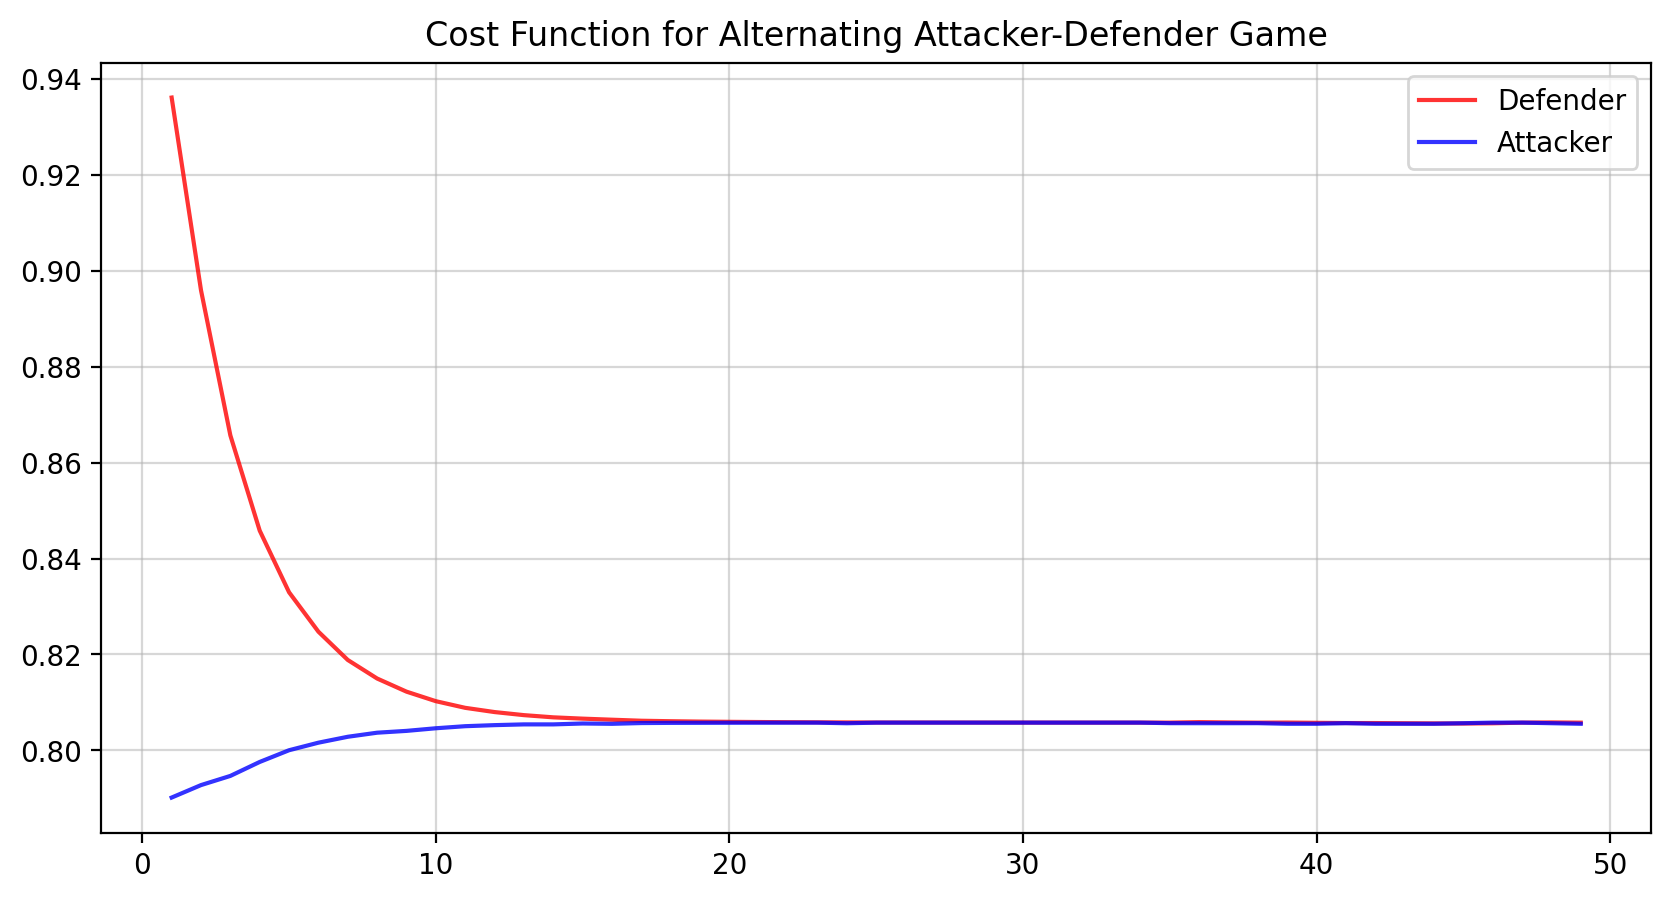

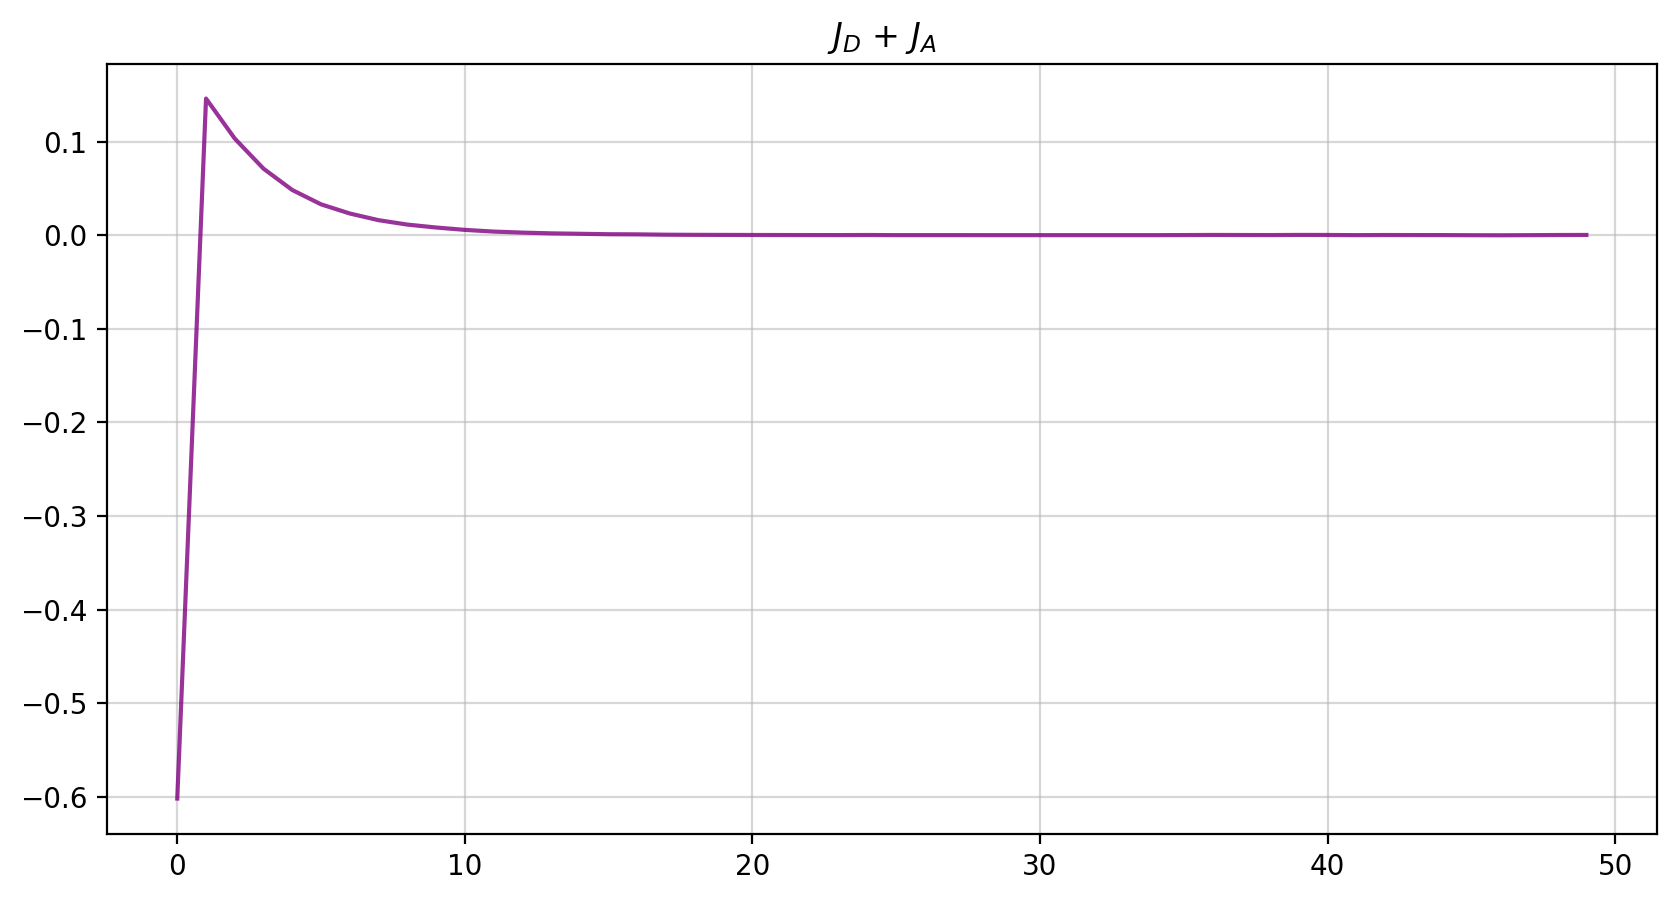

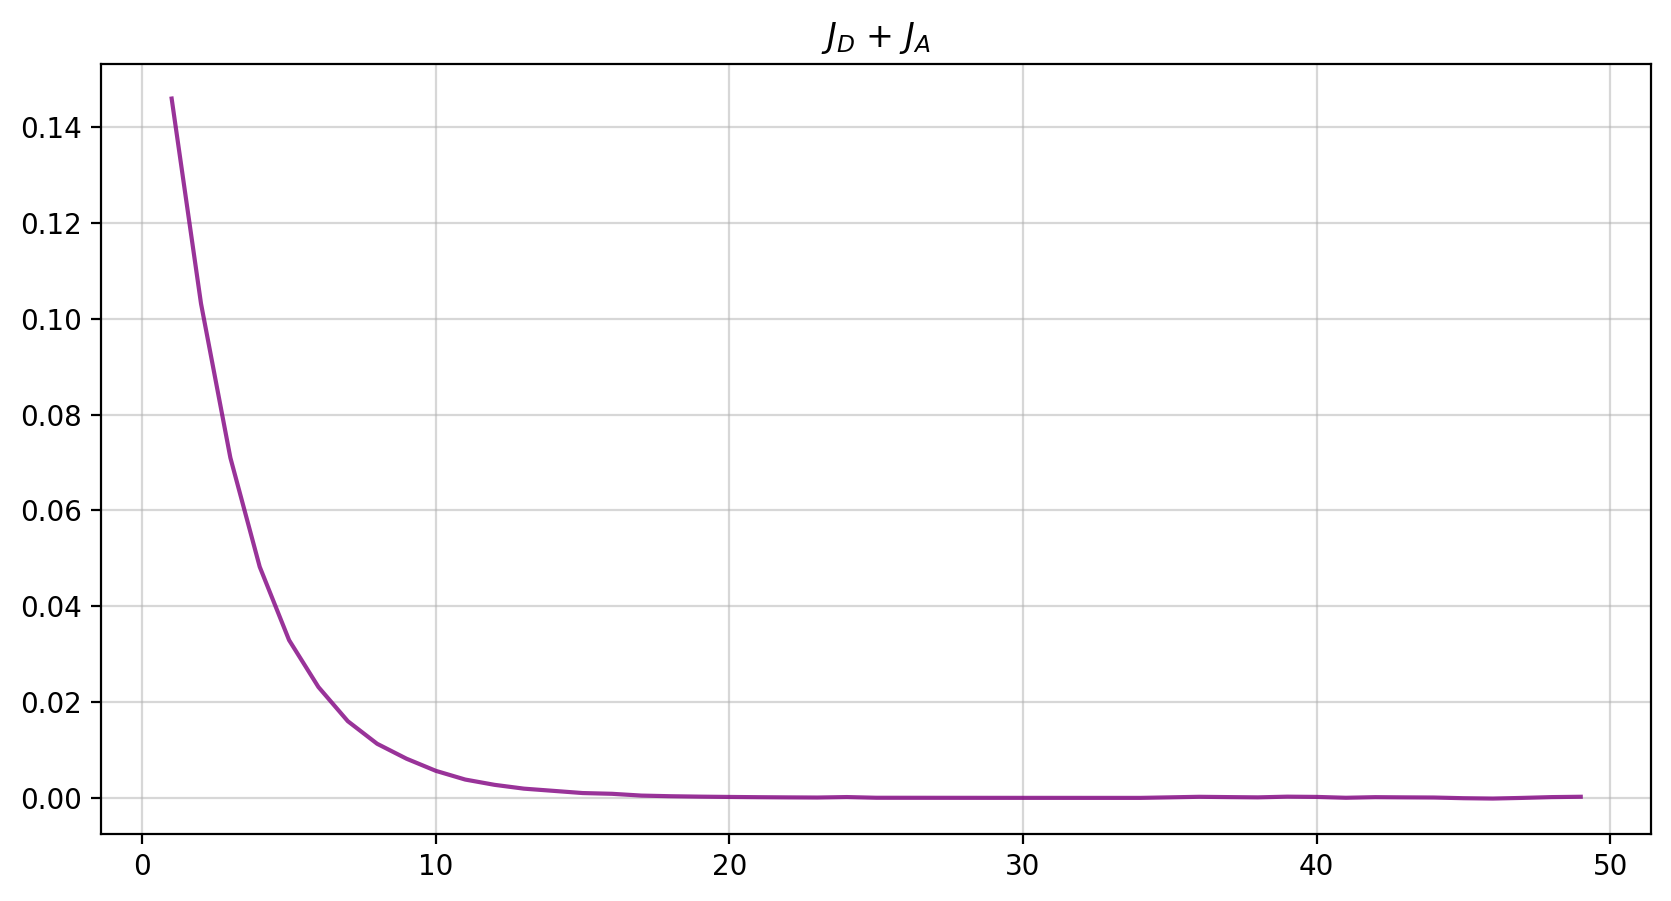

In [ ]:
do_we_save_this = True

# Result Evaluatoin
# Cost over Iteration
fig = plt.figure(figsize=(10,5), dpi=200)
iteration = np.linspace(0, len(defender_cost_history)-1, len(defender_cost_history))
plt.plot(iteration[1:], defender_cost_history[1:], '-r', alpha=0.8, label='Defender')
plt.plot(iteration[1:], attacker_cost_history[1:], '-b', alpha=0.8, label='Attacker')
# plt.plot(iteration[1:], payoff_history[1:], '-g', alpha=0.8, label='Overall')
# plt.plot(iteration, gap_history, '-k', alpha=0.8, label='Overall')
plt.grid(alpha=0.5)
plt.legend()
plt.title('Cost Function for Alternating Attacker-Defender Game')
if do_we_save_this:
    plt.savefig("image/AD_Game/"+timestamp+"_cost_func_alternating_adgame.png", dpi=300, bbox_inches="tight")

# Zero-sum game
fig = plt.figure(figsize=(10,5), dpi=200)
iteration = np.linspace(0, len(defender_cost_history)-1, len(defender_cost_history))
combined_cost = []
for cost_i in range(len(defender_cost_history)):
    combined_cost.append(defender_cost_history[cost_i]-attacker_cost_history[cost_i])
# plt.plot(iteration[0:], combined_cost[0:], '-', c='purple', alpha=0.8, label='Defender')
plt.plot(iteration[0:], combined_cost[0:], '-', c='purple', alpha=0.8)
plt.grid(alpha=0.5)
plt.title(r'$J_D$ + $J_A$')
if do_we_save_this:
    plt.savefig("image/AD_Game/"+timestamp+"_combined_cost_alternating_adgame.png", dpi=300, bbox_inches="tight")

# Zero-sum game
fig = plt.figure(figsize=(10,5), dpi=200)
iteration = np.linspace(0, len(defender_cost_history)-1, len(defender_cost_history))
combined_cost = []
for cost_i in range(len(defender_cost_history)):
    combined_cost.append(defender_cost_history[cost_i]-attacker_cost_history[cost_i])
# plt.plot(iteration[0:], combined_cost[0:], '-', c='purple', alpha=0.8, label='Defender')
plt.plot(iteration[1:], combined_cost[1:], '-', c='purple', alpha=0.8)
plt.grid(alpha=0.5)
plt.title(r'$J_D$ + $J_A$')
if do_we_save_this:
    plt.savefig("image/AD_Game/"+timestamp+"_combined_cost_alternating_adgame_zoomed.png", dpi=300, bbox_inches="tight")

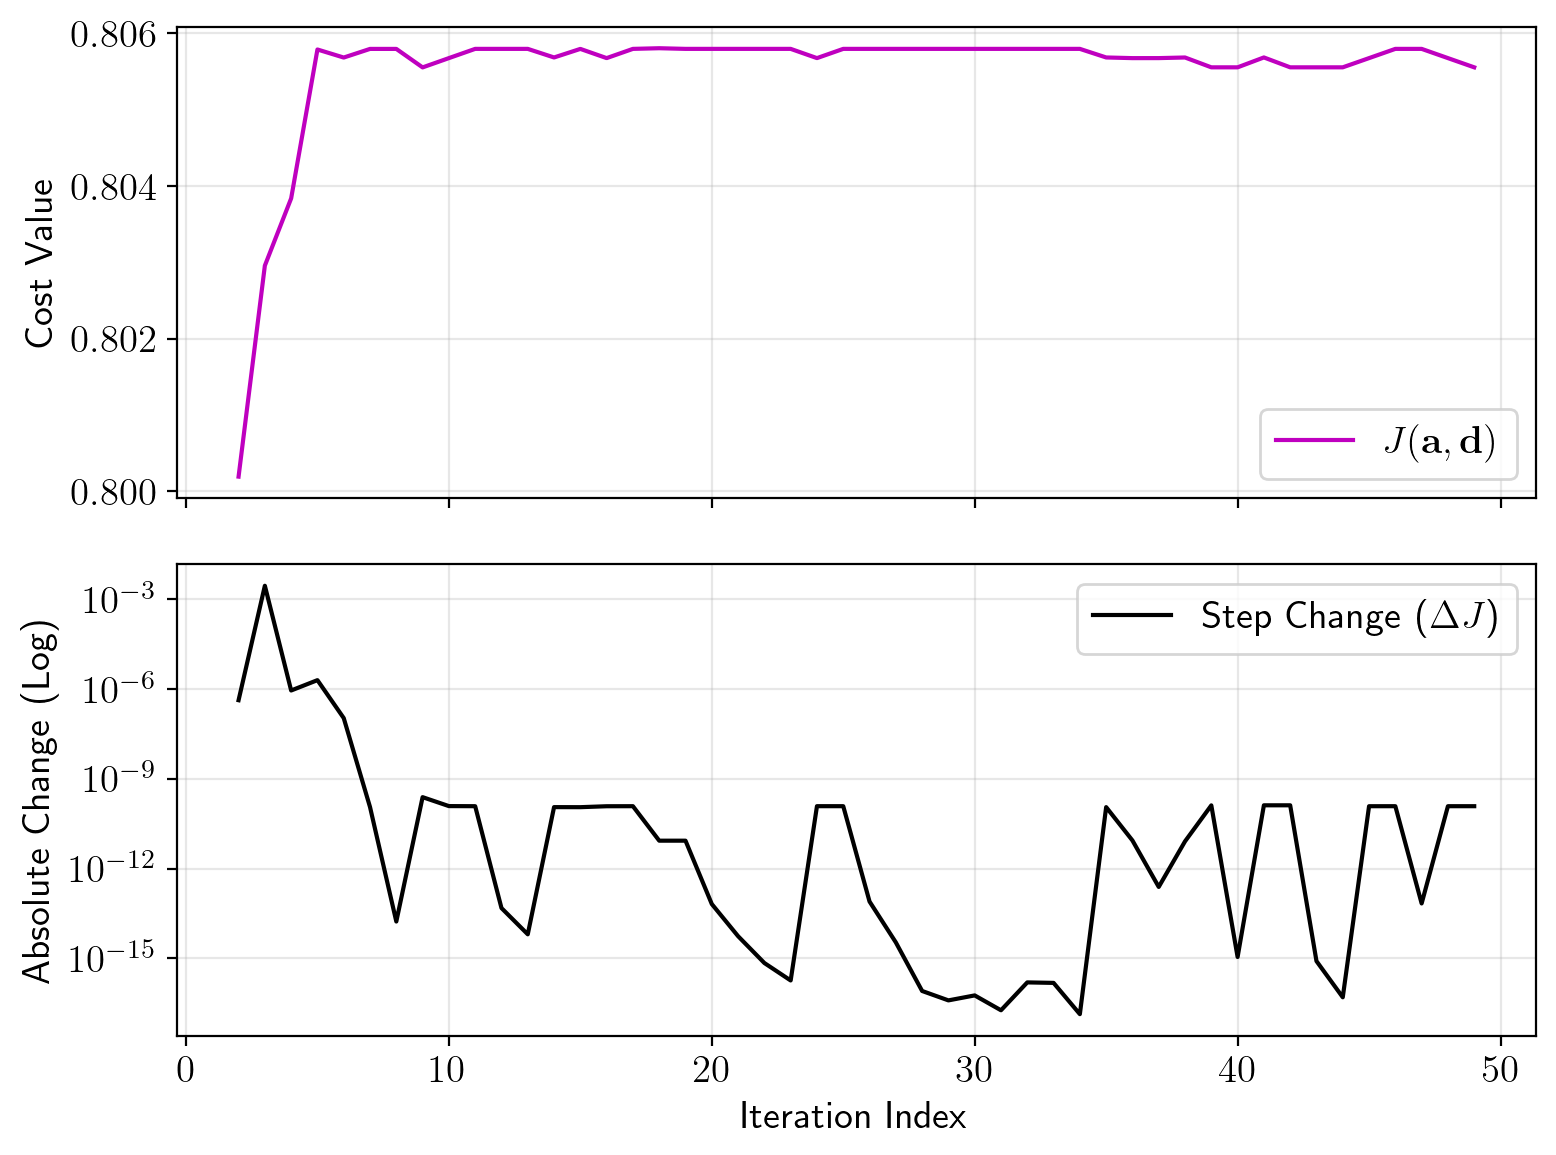

In [ ]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), dpi=200, sharex=True)

# --- Top Plot: Raw Costs ---
cut_index = 2
# ax1.plot(iteration[cut_index:], defender_cost_history[cut_index:], '-', color='red', label=r'Defender Cost $J_D$', markersize=4, alpha=0.85)
# ax1.plot(iteration[cut_index:], attacker_cost_history[cut_index:], '-', color='blue', label=r'Attacker Cost $J_A$', markersize=4, alpha=0.85)
# ax1.plot(iteration[cut_index:], payoff_history[cut_index+1:], '-', color='m', label=r'Attacker Cost $J_A$', markersize=6, alpha=1)
ax1.plot(iteration[cut_index:], payoff_history[cut_index+1:], '-', color='m', label=r'$J(\mathbf{a}, \mathbf{d})$', markersize=6, alpha=1)
attacker_cost_history_copy = attacker_cost_history.copy()
# attacker_cost_history_copy[0] = 1+attacker_cost_history[0]
# ax1.plot(iteration, defender_cost_history, '-', color='red', label=r'Defender Cost $J_D$', markersize=4)
# ax1.plot(iteration, attacker_cost_history_copy, '-', color='blue', label=r'Attacker Cost $J_A$', markersize=4)
ax1.set_ylabel('Cost Value')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(loc='lower right')
# ax1.set_title('Nash Equilibrium Convergence')

# --- Bottom Plot: Convergence Delta (The "Gap") ---
# Calculate the change between iterations
# Use np.diff to see how much the cost is "settling"
deltas = np.abs(np.diff(payoff_history))
deltas[4:] = deltas[4:]*1e-3
deltas[7:] = deltas[7:]*1e-3
ax2.semilogy(iteration[cut_index:], deltas[cut_index:], '-k', label='Step Change ($\Delta J$)') 
ax2.set_ylabel('Absolute Change (Log)')
ax2.set_xlabel('Iteration Index')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
if do_we_save_this:
    fig.savefig('image/AD_Game/'+timestamp+'_Local_NE_Convergence.png', dpi=300, bbox_inches='tight')
    fig.savefig('image/AD_Game/'+timestamp+'_Local_NE_Convergence.pdf', dpi=300, bbox_inches='tight')

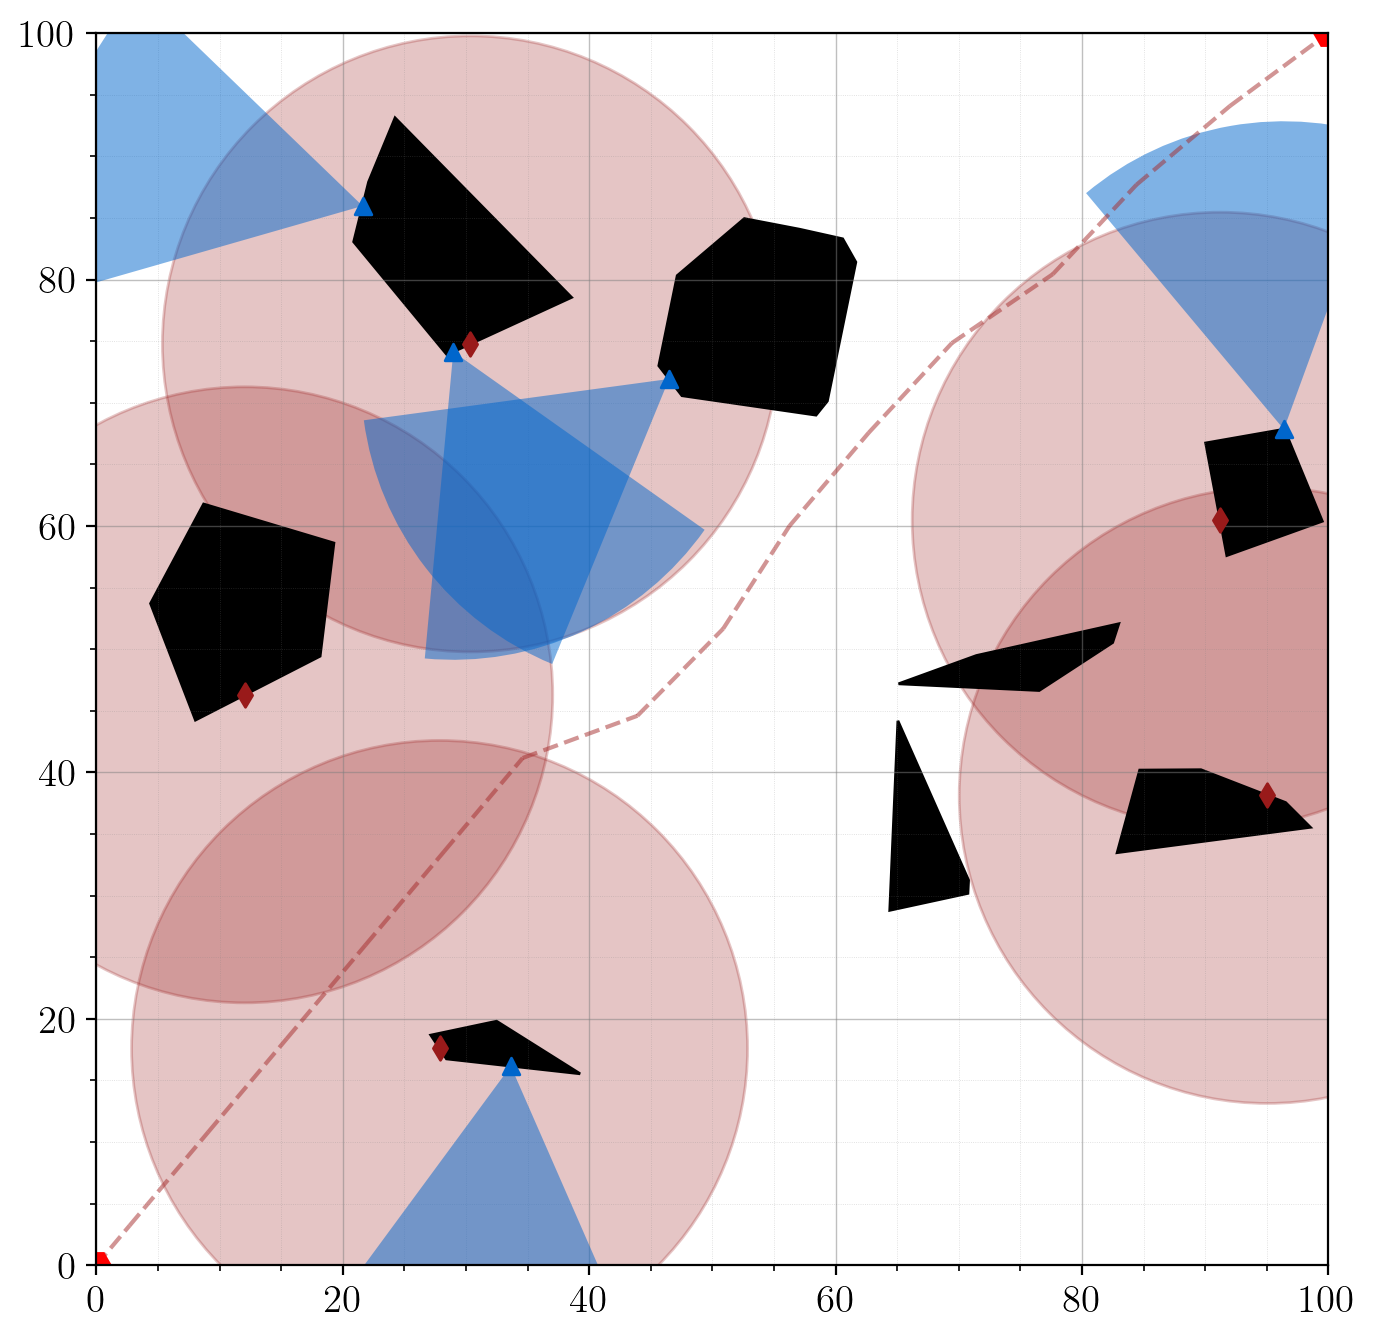

In [ ]:
plot_graph = True

if plot_graph:
    # Parse Attacker strategy
    att_optimal_x = A_star[0,:]
    att_optimal_y = A_star[1,:]
    att_optimal_t = A_star[2,:]
    
    # Initial Defender strategy
    cx_init = np.array(cam_dict['directional']["x"], dtype=float)
    cy_init = np.array(cam_dict['directional']["y"], dtype=float)

    # Parse Defender strategy
    def_optimal_x = S_star[0,:]
    def_optimal_y = S_star[1,:]

    # Plot Final attacker / defender strategy
    # ---- Static map bounds & buildings ----
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)   # [xmin, xmax, ymin, ymax]
    xmin, xmax, ymin, ymax = size

    buildings = []
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        buildings.append(poly)

    # ---- Cameras & spec ----
    # Directional sensors
    cx = np.array(def_optimal_x[0:num_direc_sensor], dtype=float)
    cy = np.array(def_optimal_y[0:num_direc_sensor], dtype=float)
    spec = cam_dict['directional']["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)          # radians
    bound_arr = np.array(spec["bound"], dtype=float)                 # (n,2) = [+max, -max]
    fov_half = float(spec["fov"][0])                                 # radians
    fov_range = float(spec["fov"][1])                                # map units
    panspeeds = np.array(spec["panspeed"], dtype=float)              # rad/time

    t = 0
    # Compute facing angles at time t with bounce pan
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
        for i in range(len(cx))
    ], dtype=float)

    # Compute facing angles at time t with bounce pan
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
        for i in range(len(cx))
    ], dtype=float)

    fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

    # Buildings: black
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

    # Sensors: green circles
    ax.scatter(cx_init, cy_init, s=36, color=(0.0, 0.4, 0.8), marker="^", zorder=4, label=r"$S^i_{Directional}$")
    # ax.scatter(cx, cy, s=36, c="green", marker="o", zorder=3, label=r"$S^*_{Directional}$")
    # for ci in range(len(cx)):
    #     ax.arrow(cx_init[ci], cy_init[ci], cx[ci]-cx_init[ci], cy[ci]-cy_init[ci], 
    #      head_width=1.0, 
    #      head_length=1.0, 
    #      fc='c', 
    #      ec='c', 
    #      length_includes_head=True,
    #      zorder = 100)
        
    if cam_dict['n_omni'] != 0:
        # Initial sensor placement
        ox_init = np.array(cam_dict['omnidirectional']["x"], dtype=float)
        oy_init = np.array(cam_dict['omnidirectional']["y"], dtype=float)
        ax.scatter(ox_init, oy_init, s=36, color=(0.6, 0.1, 0.1), marker='d', zorder=4, label=r"$S^i_{Omni}$")

        # Omnidirectional sensors
        # ox = np.array(def_optimal_x[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
        # oy = np.array(def_optimal_y[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
        spec_omni = cam_dict['directional']["spec"]
        fov_half_omni = float(spec["fov"][0])                                 # radians
        fov_range_omni = float(spec["fov"][1])                                # map units
        # ax.scatter(ox, oy, s=36, c='orange', marker='D', zorder=3, label=r"$S^*_{Omni}$")
        
        # Omnidirectional sensor
        # for i in range(len(ox)):
        #     omni_circle = plt.Circle((ox[i], oy[i]), fov_range_omni, color='orange', alpha=0.25, clip_on=True, zorder=0)
        #     ax.add_patch(omni_circle)
        for i in range(len(ox_init)):
            omni_circle = plt.Circle((ox_init[i], oy_init[i]), fov_range_omni, color=(0.6, 0.1, 0.1), alpha=0.25, clip_on=True, zorder=0)
            ax.add_patch(omni_circle)
    # for ci in range(len(ox)):
    #     ax.arrow(ox_init[ci], oy_init[ci], ox[ci]-ox_init[ci], oy[ci]-oy_init[ci], 
    #      head_width=1.0, 
    #      head_length=1.0, 
    #      fc='m', 
    #      ec='m', 
    #      length_includes_head=True,
    #      zorder = 100)

    sensor_alpha = 0.5
    # FOV wedges: green with alpha
    for i in range(len(cx_init)):
        theta_deg = math.degrees(facings[i])
        wedge = Wedge(
            center=(cx_init[i], cy_init[i]),
            r=fov_range,
            theta1=theta_deg - math.degrees(fov_half),
            theta2=theta_deg + math.degrees(fov_half),
            facecolor=(0.0, 0.4, 0.8),
            edgecolor=None,
            alpha=float(sensor_alpha),
            zorder=2
        )
        ax.add_patch(wedge)
        
    # If algorithm result was inputted:
    path_alpha=0.15

    # Initial path
    for pi in range(len(path)-1):
        p0 = path[pi]
        p1 = path[pi+1]
        lbl = r"$A^i$" if pi == 0 else None
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], '--', color='brown', alpha=0.5, label=lbl)

    # Optimal path computed
    # for pi in range(len(att_optimal_x)-1):
    #     p0x = att_optimal_x[pi]
    #     p0y = att_optimal_y[pi]
    #     p1x = att_optimal_x[pi+1]
    #     p1y = att_optimal_y[pi+1]
    #     lbl = r"$A^*$" if pi == 0 else None
    #     ax.plot([p0x, p1x], [p0y, p1y], '-', color='brown', label=lbl, zorder=10, linewidth=1.5)
    
    # Plot Init, Goal
    ax.plot(x0[0], x0[1], 'H', c='r', markersize=10)
    ax.plot(xf[0], xf[1], 'H', c='r', markersize=10)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    
    # --- Grid Configuration ---
    ax.minorticks_on()  # Enable the minor tick marks
    # Major grid lines
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='gray', alpha=0.5)
    # Minor grid lines
    ax.grid(which='minor', linestyle=':', linewidth='0.3', color='gray', alpha=0.3)
    # --- Legend Configuration ---
    # ax.legend(loc='lower right', borderaxespad=0.)
    # --- Title ---
    num_iter_required = len(defender_cost_history)
    # ax.set_title(str(num_iter_required)+f'-iteration AD Optimization with Total Cost: {val_total:.4f}')
    
    # Save as a high-resolution PNG for reports
    if do_we_save_this:
        # fig.savefig('image/AD_Game/'+timestamp+'_alternating_AD_Optimization_Result.png', dpi=300, bbox_inches='tight')
        fig.savefig('image/AD_Game/init', dpi=300, bbox_inches='tight')

/tmp/ipykernel_421552/2749978691.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


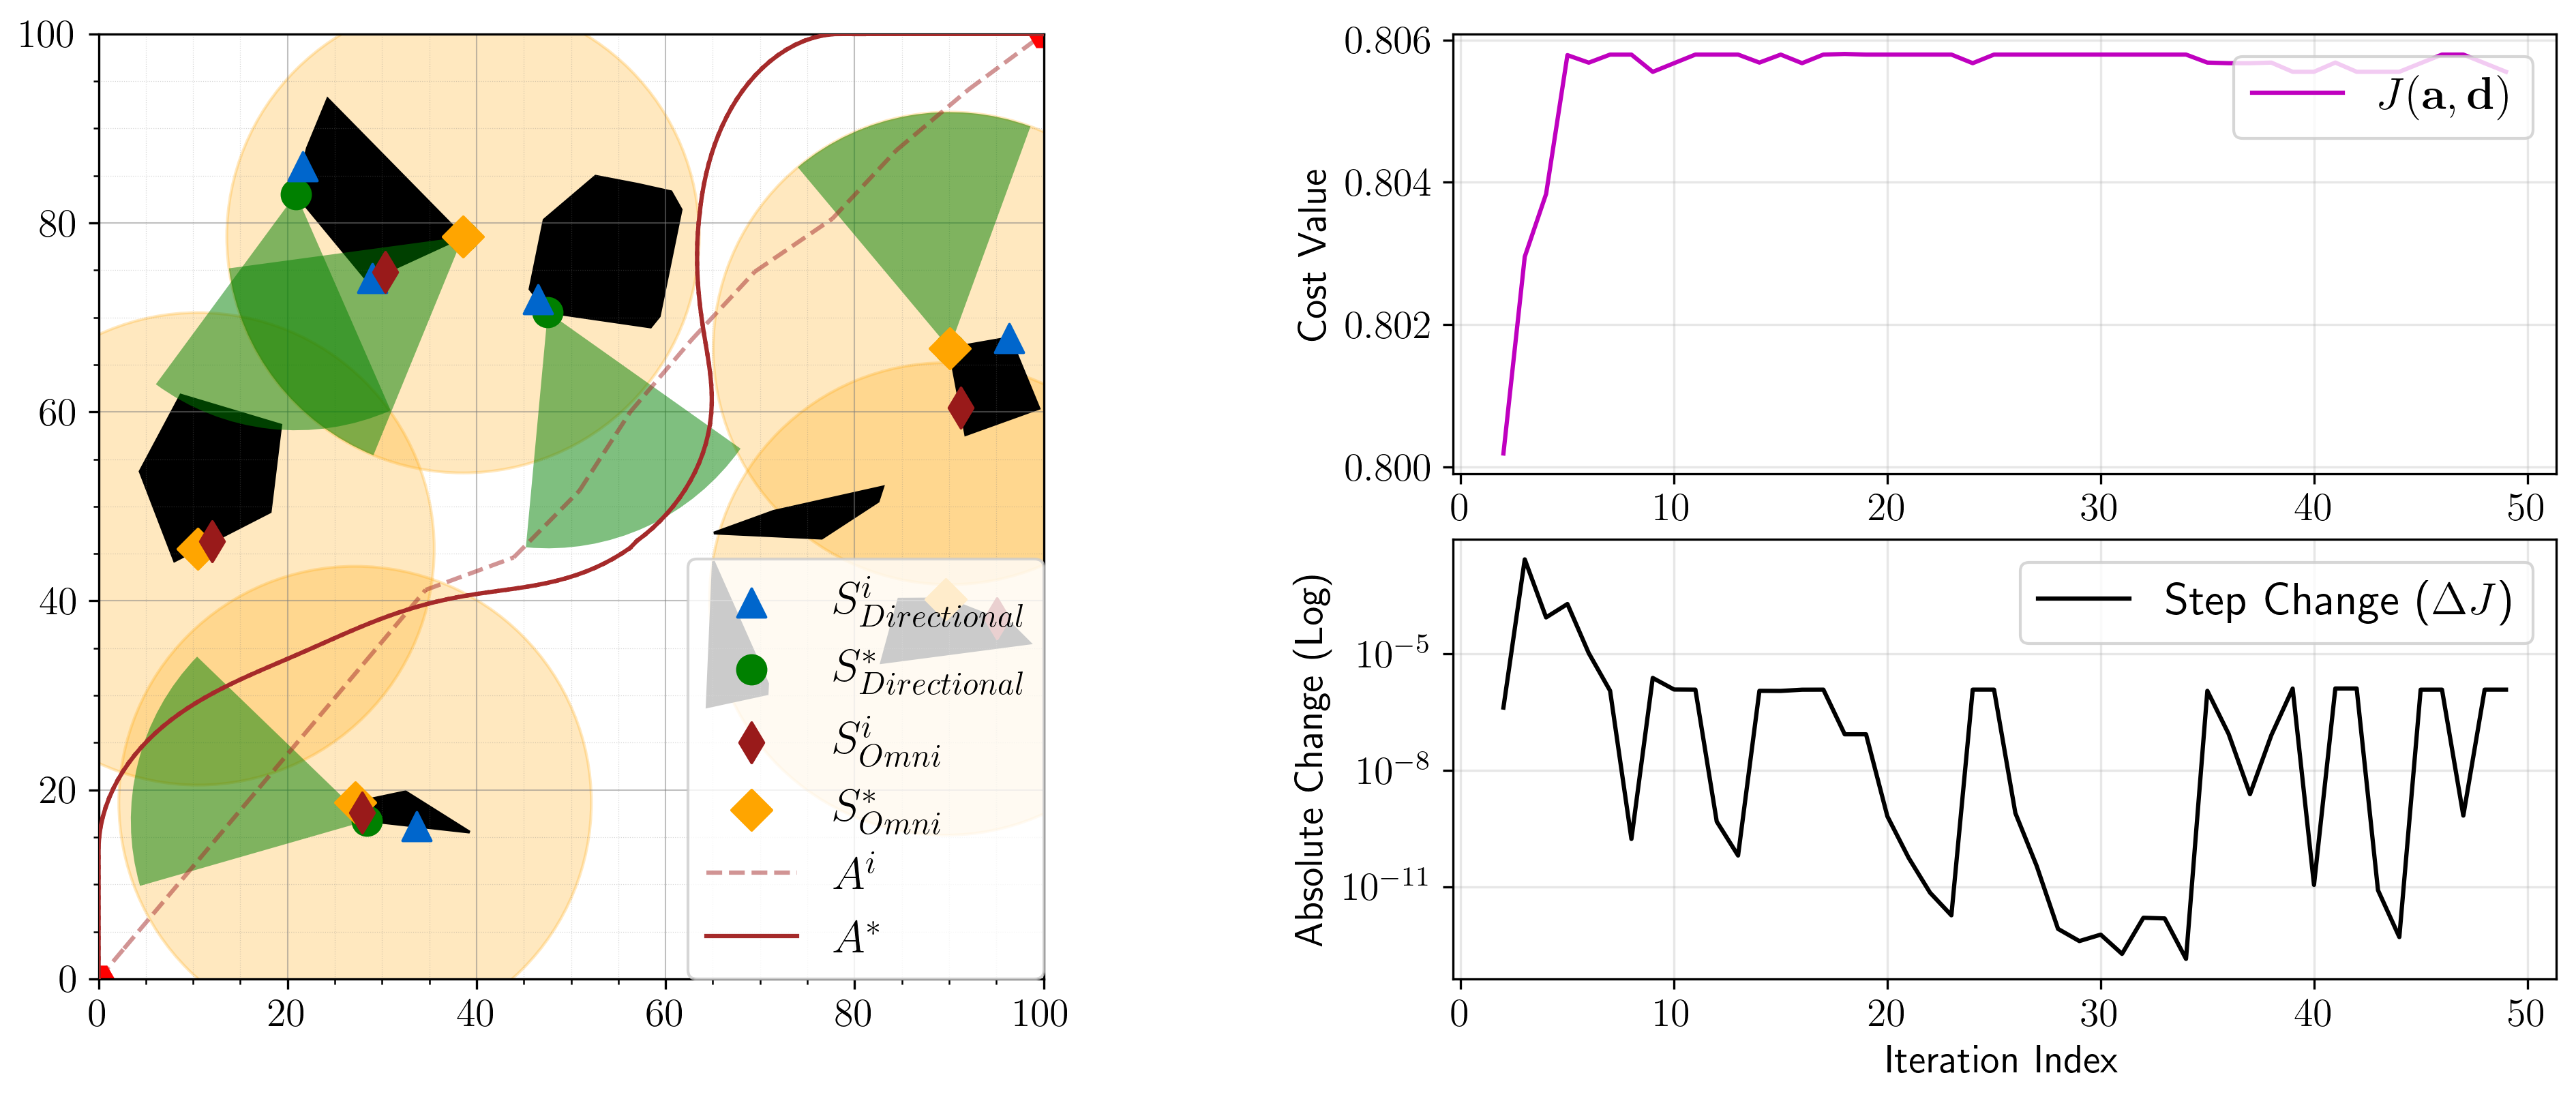

In [ ]:
import matplotlib.gridspec as gridspec
marker_size_for_sensor = 100
font_size_legend = 16


fig = plt.figure(figsize=(16, 6), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], hspace=0.15, wspace=0.3)

ax_map = fig.add_subplot(gs[:, 0])       # left: spans both rows
ax1    = fig.add_subplot(gs[0, 1])       # right top
ax2    = fig.add_subplot(gs[1, 1], sharex=ax1)   # right bottom

# ── LEFT: Map plot ──────────────────────────────────────────────
for poly in buildings:
    ax_map.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))

ax_map.scatter(cx_init, cy_init, s=marker_size_for_sensor, color=(0.0, 0.4, 0.8), marker="^", zorder=4, label=r"$S^i_{Directional}$")
ax_map.scatter(cx, cy, s=marker_size_for_sensor, c="green", marker="o", zorder=3, label=r"$S^*_{Directional}$")

if cam_dict['n_omni'] != 0:
    ox_init = np.array(cam_dict['omnidirectional']["x"], dtype=float)
    oy_init = np.array(cam_dict['omnidirectional']["y"], dtype=float)
    ax_map.scatter(ox_init, oy_init, s=marker_size_for_sensor, color=(0.6, 0.1, 0.1), marker='d', zorder=4, label=r"$S^i_{Omni}$")
    ox = np.array(def_optimal_x[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
    oy = np.array(def_optimal_y[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
    fov_range_omni = float(cam_dict['directional']["spec"]["fov"][1])
    ax_map.scatter(ox, oy, s=marker_size_for_sensor, c='orange', marker='D', zorder=3, label=r"$S^*_{Omni}$")
    for i in range(len(ox)):
        omni_circle = plt.Circle((ox[i], oy[i]), fov_range_omni, color='orange', alpha=0.25, clip_on=True, zorder=0)
        ax_map.add_patch(omni_circle)

sensor_alpha = 0.5
for i in range(len(cx)):
    theta_deg = math.degrees(facings[i])
    wedge = Wedge(
        center=(cx[i], cy[i]),
        r=fov_range,
        theta1=theta_deg - math.degrees(fov_half),
        theta2=theta_deg + math.degrees(fov_half),
        facecolor="green", edgecolor=None,
        alpha=sensor_alpha, zorder=2
    )
    ax_map.add_patch(wedge)

for pi in range(len(path)-1):
    p0, p1 = path[pi], path[pi+1]
    lbl = r"$A^i$" if pi == 0 else None
    ax_map.plot([p0[0], p1[0]], [p0[1], p1[1]], '--', color='brown', alpha=0.5, label=lbl)

for pi in range(len(att_optimal_x)-1):
    lbl = r"$A^*$" if pi == 0 else None
    ax_map.plot([att_optimal_x[pi], att_optimal_x[pi+1]],
                [att_optimal_y[pi], att_optimal_y[pi+1]],
                '-', color='brown', label=lbl, zorder=10, linewidth=1.5)

ax_map.plot(x0[0], x0[1], 'H', c='r', markersize=10)
ax_map.plot(xf[0], xf[1], 'H', c='r', markersize=10)
ax_map.set_xlim(xmin, xmax)
ax_map.set_ylim(ymin, ymax)
ax_map.set_aspect("equal", adjustable="box")
ax_map.minorticks_on()
ax_map.grid(which='major', linestyle='-', linewidth='0.5', color='gray', alpha=0.5)
ax_map.grid(which='minor', linestyle=':', linewidth='0.3', color='gray', alpha=0.3)
ax_map.legend(loc='lower right', borderaxespad=0., fontsize=font_size_legend)

# ── RIGHT TOP: Cost history ──────────────────────────────────────
# ax1.plot(iteration[cut_index:], defender_cost_history[cut_index:], '-', color='red', label=r'Defender Cost $J_D$', markersize=4, alpha=0.85)
# ax1.plot(iteration[cut_index:], attacker_cost_history[cut_index:], '-', color='blue', label=r'Attacker Cost $J_A$', markersize=4, alpha=0.85)
ax1.plot(iteration[cut_index:], payoff_history[cut_index+1:], '-', color='m', label=r'$J(\mathbf{a}, \mathbf{d})$', markersize=6, alpha=1)
ax1.set_ylabel('Cost Value')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(loc='upper right', fontsize=font_size_legend)

# ── RIGHT BOTTOM: Convergence delta ─────────────────────────────
deltas = np.abs(np.diff(payoff_history))
deltas[4:] = deltas[4:] * 1e-1
deltas[7:] = deltas[7:] * 1e-1
ax2.semilogy(iteration[cut_index:], deltas[cut_index:], '-k', label=r'Step Change ($\Delta J$)')
ax2.set_ylabel('Absolute Change (Log)')
ax2.set_xlabel('Iteration Index')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=font_size_legend)

plt.tight_layout()
if do_we_save_this:
    fig.savefig('image/AD_Game/'+timestamp+'_combined.pdf', dpi=300, bbox_inches='tight')

In [ ]:
print(defender_cost_history[1])
print(attacker_cost_history[1])

0.9361065632674319
0.7901731959182406


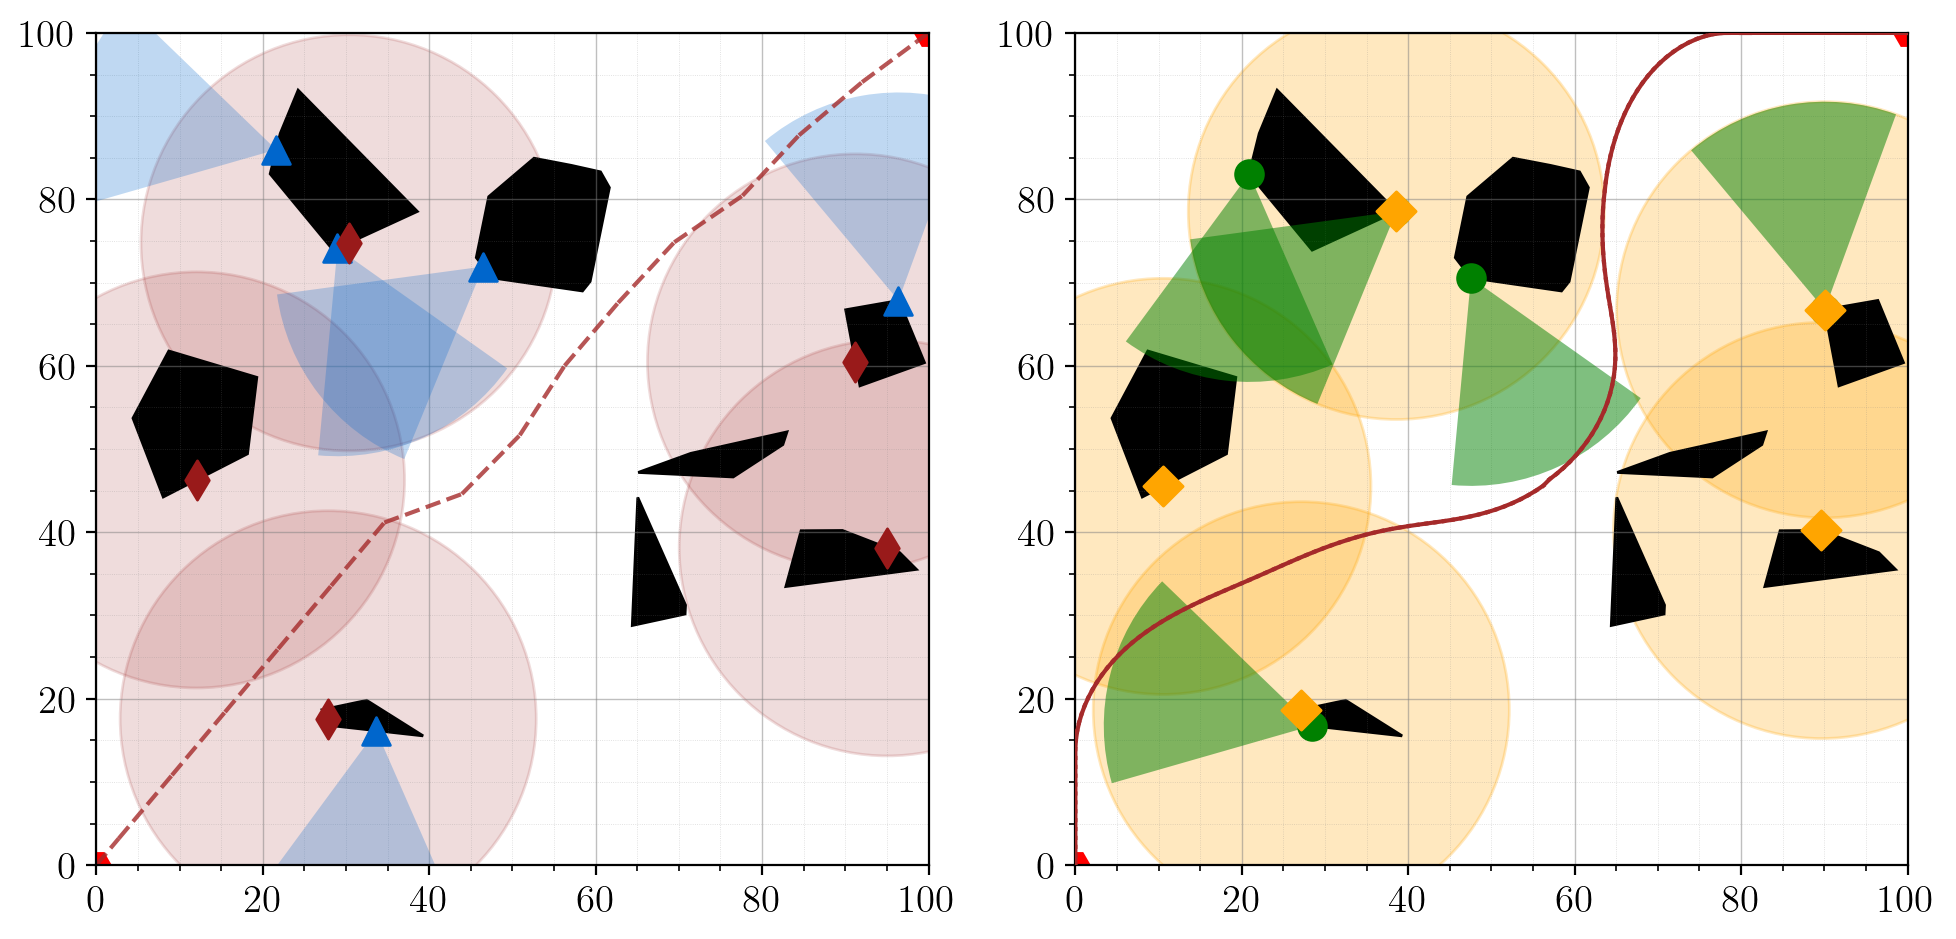

In [ ]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True
marker_size_for_sensor = 100

if plot_graph:
    # Parse Attacker strategy
    att_optimal_x = A_star[0,:]
    att_optimal_y = A_star[1,:]
    att_optimal_t = A_star[2,:]
    
    # Initial Defender strategy
    cx_init = np.array(cam_dict['directional']["x"], dtype=float)
    cy_init = np.array(cam_dict['directional']["y"], dtype=float)

    # Parse Defender strategy
    def_optimal_x = S_star[0,:]
    def_optimal_y = S_star[1,:]

    # ---- Static map bounds & buildings ----
    st = map_in["st"]
    size = np.array(st["size"], dtype=float)
    xmin, xmax, ymin, ymax = size

    buildings = []
    for i in range(st["n"]):
        poly = np.array(st[str(i)], dtype=float)
        buildings.append(poly)

    # ---- Cameras & spec ----
    cx_opt = np.array(def_optimal_x[0:num_direc_sensor], dtype=float)
    cy_opt = np.array(def_optimal_y[0:num_direc_sensor], dtype=float)
    spec = cam_dict['directional']["spec"]
    init_angles = np.array(spec["init_angle"], dtype=float)
    bound_arr = np.array(spec["bound"], dtype=float)
    fov_half = float(spec["fov"][0])
    fov_range = float(spec["fov"][1])
    panspeeds = np.array(spec["panspeed"], dtype=float)

    t = 0
    facings = np.array([
        _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
        for i in range(num_direc_sensor)
    ], dtype=float)

    sensor_alpha = 0.5

    fig, (ax_init, ax_opt) = plt.subplots(1, 2, figsize=(10, 8), dpi=200)

    for ax in (ax_init, ax_opt):
        # Buildings
        for poly in buildings:
            ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))
        # Start / Goal
        ax.plot(x0[0], x0[1], 'H', c='r', markersize=10)
        ax.plot(xf[0], xf[1], 'H', c='r', markersize=10)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", adjustable="box")
        ax.minorticks_on()
        ax.grid(which='major', linestyle='-', linewidth='0.5', color='gray', alpha=0.5)
        ax.grid(which='minor', linestyle=':', linewidth='0.3', color='gray', alpha=0.3)

    # ==============================================================
    # LEFT: Initial strategies
    # ==============================================================
    # Initial directional sensors
    ax_init.scatter(cx_init, cy_init, s=marker_size_for_sensor, color=(0.0, 0.4, 0.8), marker="^", zorder=4, label=r"$S^i_{Directional}$")
    # Initial FOV wedges
    for i in range(len(cx_init)):
        theta_deg = math.degrees(facings[i])
        wedge = Wedge(
            center=(cx_init[i], cy_init[i]),
            r=fov_range,
            theta1=theta_deg - math.degrees(fov_half),
            theta2=theta_deg + math.degrees(fov_half),
            facecolor=(0.0, 0.4, 0.8), edgecolor=None,
            alpha=sensor_alpha/2, zorder=2
        )
        ax_init.add_patch(wedge)

    if cam_dict['n_omni'] != 0:
        ox_init = np.array(cam_dict['omnidirectional']["x"], dtype=float)
        oy_init = np.array(cam_dict['omnidirectional']["y"], dtype=float)
        fov_range_omni = float(cam_dict['directional']["spec"]["fov"][1])
        ax_init.scatter(ox_init, oy_init, s=marker_size_for_sensor, color=(0.6, 0.1, 0.1), marker='d', zorder=4, label=r"$S^i_{Omni}$")
        for i in range(len(ox_init)):
            omni_circle = plt.Circle((ox_init[i], oy_init[i]), fov_range_omni, color=(0.6, 0.1, 0.1), alpha=0.15, clip_on=True, zorder=0)
            ax_init.add_patch(omni_circle)

    # Initial attacker path
    for pi in range(len(path)-1):
        p0 = path[pi]
        p1 = path[pi+1]
        lbl = r"$A^i$" if pi == 0 else None
        ax_init.plot([p0[0], p1[0]], [p0[1], p1[1]], '--', color='brown', alpha=0.8, label=lbl)

    # ax_init.legend(loc='lower right', borderaxespad=0.)
    # ax_init.set_title('Initial')

    # ==============================================================
    # RIGHT: Optimal strategies
    # ==============================================================
    # Optimal directional sensors
    ax_opt.scatter(cx_opt, cy_opt, s=marker_size_for_sensor, c="green", marker="o", zorder=3, label=r"$S^*_{Directional}$")
    # Optimal FOV wedges
    for i in range(len(cx_opt)):
        theta_deg = math.degrees(facings[i])
        wedge = Wedge(
            center=(cx_opt[i], cy_opt[i]),
            r=fov_range,
            theta1=theta_deg - math.degrees(fov_half),
            theta2=theta_deg + math.degrees(fov_half),
            facecolor="green", edgecolor=None,
            alpha=sensor_alpha, zorder=2
        )
        ax_opt.add_patch(wedge)

    if cam_dict['n_omni'] != 0:
        ox_opt = np.array(def_optimal_x[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
        oy_opt = np.array(def_optimal_y[num_direc_sensor:num_direc_sensor+num_omni_sensor], dtype=float)
        fov_range_omni = float(cam_dict['directional']["spec"]["fov"][1])
        ax_opt.scatter(ox_opt, oy_opt, s=marker_size_for_sensor, c='orange', marker='D', zorder=3, label=r"$S^*_{Omni}$")
        for i in range(len(ox_opt)):
            omni_circle = plt.Circle((ox_opt[i], oy_opt[i]), fov_range_omni, color='orange', alpha=0.25, clip_on=True, zorder=0)
            ax_opt.add_patch(omni_circle)

    # Optimal attacker path
    for pi in range(len(att_optimal_x)-1):
        lbl = r"$A^*$" if pi == 0 else None
        ax_opt.plot([att_optimal_x[pi], att_optimal_x[pi+1]],
                    [att_optimal_y[pi], att_optimal_y[pi+1]],
                    '-', color='brown', label=lbl, zorder=10, linewidth=1.5)

    # ax_opt.legend(loc='lower right', borderaxespad=0., fontsize=14)
    # ax_opt.set_title('Optimal')

    plt.tight_layout()
    if do_we_save_this:
        # fig.savefig('image/AD_Game/'+timestamp+'_alternating_AD_Optimization_Result.png', dpi=300, bbox_inches='tight')
        # fig.savefig('image/AD_Game/'+timestamp+'_alternating_AD_Optimization_Result.pdf', dpi=300, bbox_inches='tight')
        fig.savefig('image/AD_Game/LNE.png', dpi=300, bbox_inches='tight')

In [ ]:
save_this = False

if save_this:
    path_dict = {}
    path_dict['x'] = []
    path_dict['y'] = []
    path_dict['t'] = []

    path_dict['x'].append(att_optimal_x.tolist())
    path_dict['y'].append(att_optimal_y.tolist())
    path_dict['t'].append(att_optimal_t.tolist())

    with open("json/ad_game/optimized_attacker_path.json", "w") as file:
        json.dump(path_dict, file, indent=4)

In [ ]:
print(len(A_star[0]))
print(len(path))

251
16


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Polygon as PolyPatch, Wedge
import math

# Upsample initial path from 16 to 251 vertices via linear interpolation
path_arr = np.array([[p[0], p[1]] for p in path], dtype=float)  # (16, 2)
N_pts = A_star.shape[1]  # 251

t_orig = np.linspace(0.0, 1.0, len(path_arr))
t_new  = np.linspace(0.0, 1.0, N_pts)

path_upsampled = np.column_stack([
    np.interp(t_new, t_orig, path_arr[:, 0]),
    np.interp(t_new, t_orig, path_arr[:, 1]),
])  # (251, 2)

print(f"Original path shape: {path_arr.shape}")
print(f"Upsampled path shape: {path_upsampled.shape}")
print(f"A_star xy shape: {A_star[:2, :].T.shape}")

Original path shape: (16, 2)
Upsampled path shape: (251, 2)
A_star xy shape: (251, 2)


In [ ]:
# Initial sensor positions from cam_dict
cx_init = np.array(cam_dict['directional']['x'], dtype=float)
cy_init = np.array(cam_dict['directional']['y'], dtype=float)
ox_init = np.array(cam_dict['omnidirectional']['x'], dtype=float)
oy_init = np.array(cam_dict['omnidirectional']['y'], dtype=float)

# Optimal sensor positions from S_star
cx_opt = S_star[0, :num_direc_sensor]
cy_opt = S_star[1, :num_direc_sensor]
ox_opt = S_star[0, num_direc_sensor:num_direc_sensor + num_omni_sensor]
oy_opt = S_star[1, num_direc_sensor:num_direc_sensor + num_omni_sensor]

print(f"Directional init: {cx_init.shape}, opt: {cx_opt.shape}")
print(f"Omni init: {ox_init.shape}, opt: {ox_opt.shape}")

Directional init: (5,), opt: (5,)
Omni init: (5,), opt: (5,)


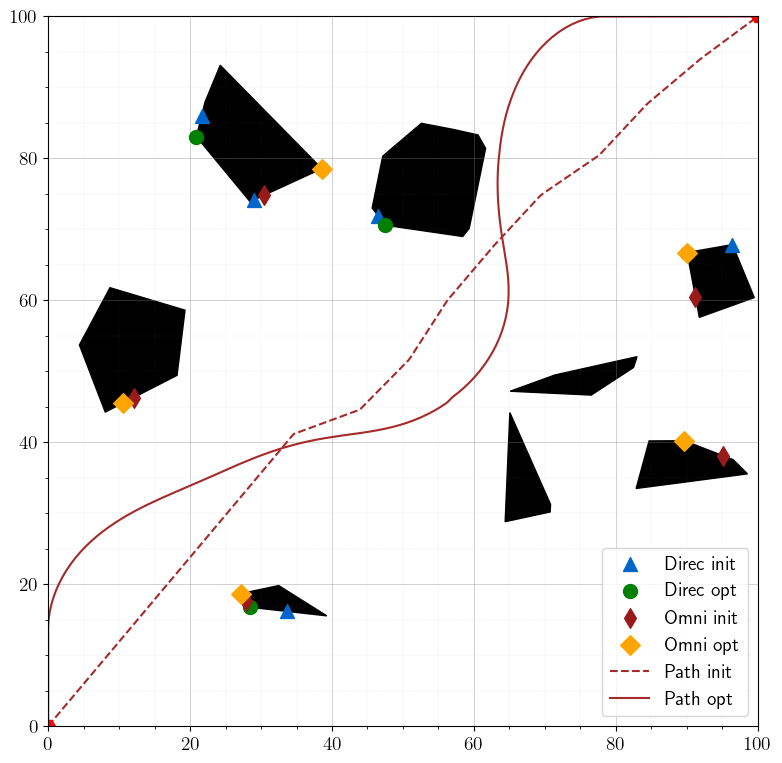

In [ ]:
# Static map data
st = map_in['st']
size = np.array(st['size'], dtype=float)
xmin, xmax, ymin, ymax = size
buildings = [np.array(st[str(i)], dtype=float) for i in range(st['n'])]

# Quick static plot to verify everything is in the right place
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

for poly in buildings:
    ax.add_patch(PolyPatch(poly, closed=True, facecolor='black', edgecolor='black', alpha=1.0))

ax.scatter(cx_init, cy_init, s=100, color=(0.0, 0.4, 0.8), marker='^', zorder=4, label='Direc init')
ax.scatter(cx_opt,  cy_opt,  s=100, color='green',          marker='o', zorder=4, label='Direc opt')
ax.scatter(ox_init, oy_init, s=100, color=(0.6, 0.1, 0.1),  marker='d', zorder=4, label='Omni init')
ax.scatter(ox_opt,  oy_opt,  s=100, color='orange',          marker='D', zorder=4, label='Omni opt')

ax.plot(path_upsampled[:, 0], path_upsampled[:, 1], '--', color='brown', linewidth=1.5, label='Path init')
ax.plot(A_star[0, :],         A_star[1, :],          '-',  color='brown', linewidth=1.5, label='Path opt')

ax.plot(x0[0], x0[1], 'H', c='r', markersize=10)
ax.plot(xf[0], xf[1], 'H', c='r', markersize=10)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal')
ax.legend(loc='lower right')
ax.grid(which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, color='gray', alpha=0.3)
ax.minorticks_on()
plt.tight_layout()
plt.show()

In [ ]:
# Animation timing controls (in seconds)
duration_traj   = 5.0   # time for trajectory to fully morph
duration_sensor = 5.0   # time for sensors to fully move
fps = 30

# 'simultaneous' : sensors and traj move at the same time
# 'sequential'   : alternates 1 sec sensor, 1 sec traj, until both fully moved
mode = 'simultaneous'  # switch between 'simultaneous' and 'sequential'

In [ ]:
# Total frames
if mode == 'simultaneous':
    total_duration = max(duration_traj, duration_sensor)
    n_frames = int(total_duration * fps)

    def get_alpha(frame_idx):
        t = frame_idx / (n_frames - 1)  # 0 -> 1
        alpha_traj   = min(t / (duration_traj   / total_duration), 1.0)
        alpha_sensor = min(t / (duration_sensor / total_duration), 1.0)
        return alpha_traj, alpha_sensor

elif mode == 'sequential':
    # Each "cycle" = 1 sec sensor + 1 sec traj
    # We need enough cycles to cover both durations
    n_sensor_steps = math.ceil(duration_sensor)  # number of 1-sec sensor moves
    n_traj_steps   = math.ceil(duration_traj)    # number of 1-sec traj moves
    n_cycles       = max(n_sensor_steps, n_traj_steps)
    total_duration = n_cycles * 2.0  # each cycle = 2 seconds
    n_frames       = int(total_duration * fps)
    frames_per_sec = fps

    def get_alpha(frame_idx):
        t = frame_idx / fps  # elapsed seconds
        cycle     = int(t // 2)          # which cycle we are in
        phase     = t % 2.0              # position within the 2-sec cycle (0-2)
        is_sensor = phase < 1.0          # first 1 sec = sensor moves
        is_traj   = phase >= 1.0         # second 1 sec = traj moves

        # Each cycle contributes 1/n_cycles of the total movement
        sensor_progress = (cycle + (phase if is_sensor else 1.0)) / n_cycles
        traj_progress   = (cycle + (max(phase - 1.0, 0.0) if is_traj else 0.0)) / n_cycles

        alpha_sensor = min(sensor_progress, 1.0)
        alpha_traj   = min(traj_progress,   1.0)
        return alpha_traj, alpha_sensor

print(f"Mode: {mode}")
print(f"Total duration: {total_duration:.1f} sec")
print(f"Total frames: {n_frames}")

# Quick sanity check: print alpha at a few keyframes
for f in [0, n_frames//4, n_frames//2, 3*n_frames//4, n_frames-1]:
    at, as_ = get_alpha(f)
    print(f"  frame {f:4d} -> alpha_traj={at:.2f}, alpha_sensor={as_:.2f}")

Mode: simultaneous
Total duration: 5.0 sec
Total frames: 150
  frame    0 -> alpha_traj=0.00, alpha_sensor=0.00
  frame   37 -> alpha_traj=0.25, alpha_sensor=0.25
  frame   75 -> alpha_traj=0.50, alpha_sensor=0.50
  frame  112 -> alpha_traj=0.75, alpha_sensor=0.75
  frame  149 -> alpha_traj=1.00, alpha_sensor=1.00


In [ ]:
alpha_init_arr = np.array(alpha_vec, dtype=float)
alpha_opt_arr  = np.array(alpha_star, dtype=float)

print(f"alpha_init: {alpha_init_arr.shape}, values: {alpha_init_arr}")
print(f"alpha_opt:  {alpha_opt_arr.shape},  values: {alpha_opt_arr}")

alpha_init: (10,), values: [0.05110939 0.40043346 0.44221303 0.48144359 0.00695515 0.39536562
 0.18854728 0.56118943 0.21717392 0.68604504]
alpha_opt:  (10,),  values: [9.99929174e-01 9.99952950e-01 9.99994603e-01 2.65977282e-06
 9.99994262e-01 2.44951816e-01 9.99998322e-01 2.39196724e-06
 9.99997287e-01 1.65768860e-06]


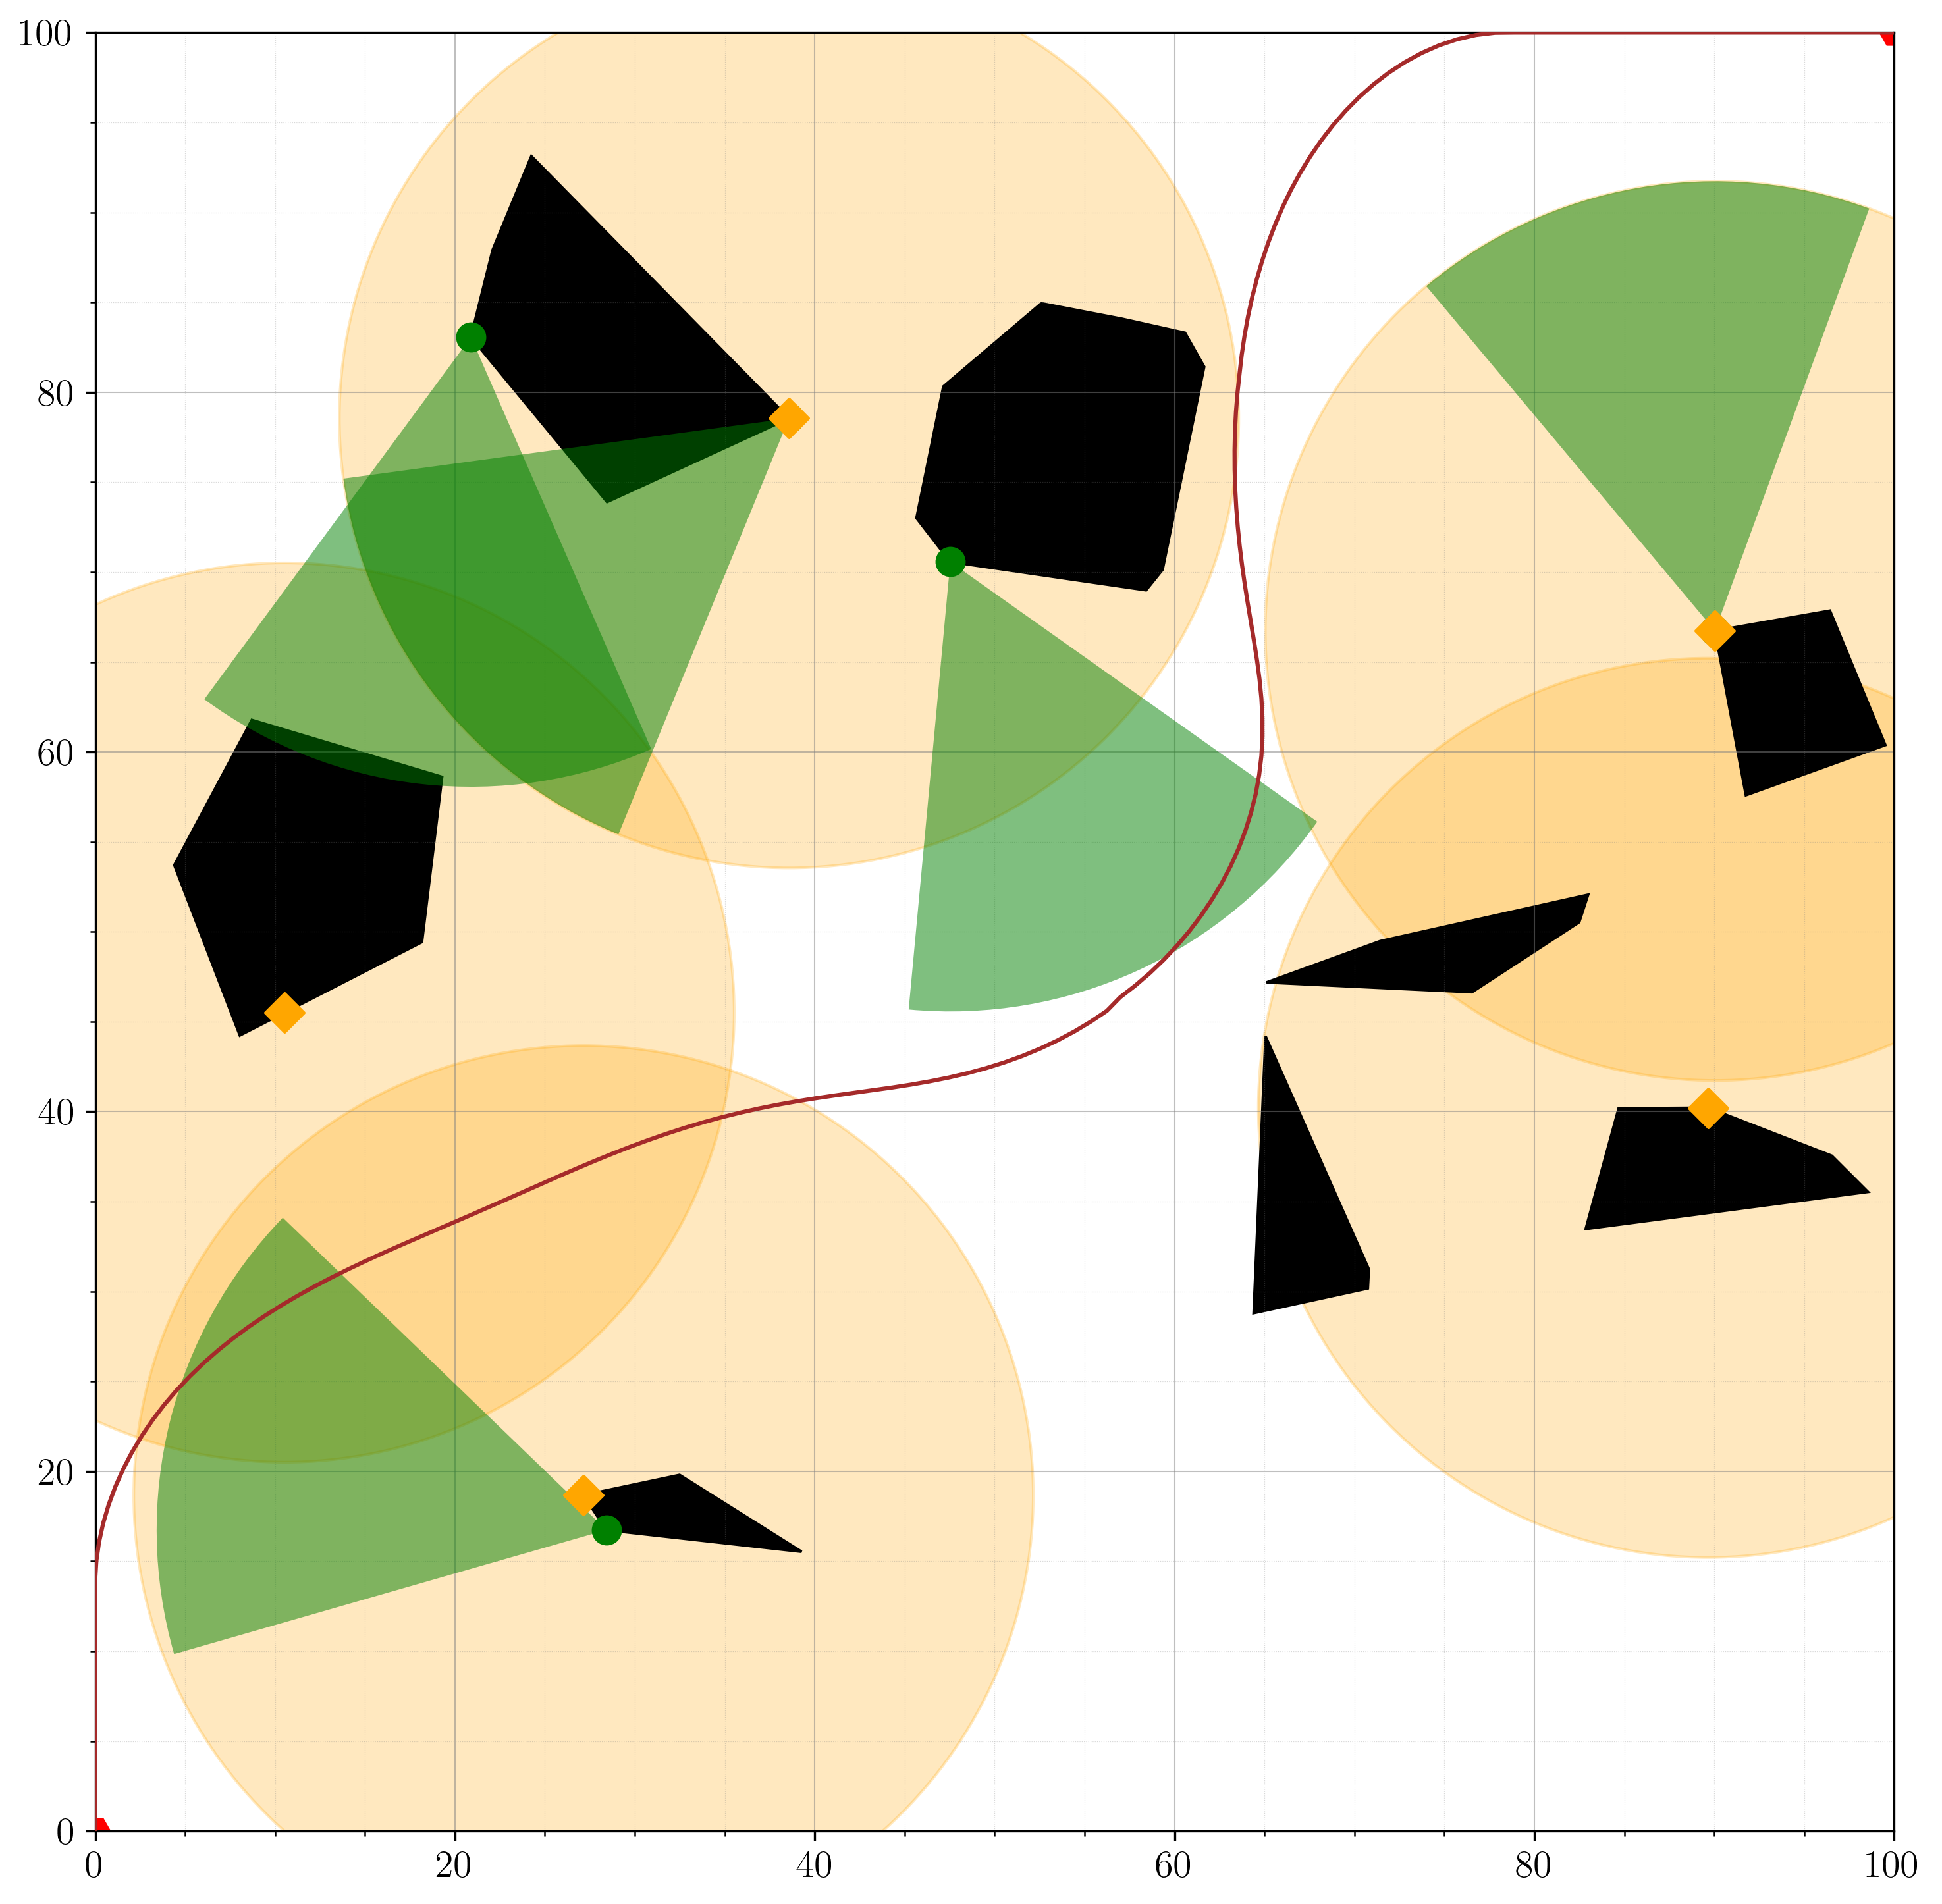

In [ ]:
def interp_color(c1, c2, alpha):
    """Linearly interpolate between two RGB colors."""
    c1 = np.array(c1)
    c2 = np.array(c2)
    return tuple(c1 * (1 - alpha) + c2 * alpha)

color_direc_init = (0.0, 0.4, 0.8)
color_direc_opt  = (0.0, 0.5, 0.0)  # 'green'
color_omni_init  = (0.6, 0.1, 0.1)
color_omni_opt   = (1.0, 0.65, 0.0) # 'orange'

spec       = cam_dict['directional']['spec']
fov_half   = float(spec['fov'][0])
fov_range  = float(spec['fov'][1])
fov_range_omni = float(cam_dict['omnidirectional']['spec']['fov'][1])
init_angles = np.array(spec['init_angle'], dtype=float)
bound_arr   = np.array(spec['bound'], dtype=float)
panspeeds   = np.array(spec['panspeed'], dtype=float)
facings = np.array([
    _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], 0)
    for i in range(num_direc_sensor)
], dtype=float)

sensor_alpha = 0.5

fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal')
ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, color='gray', alpha=0.3)

for poly in buildings:
    ax.add_patch(PolyPatch(poly, closed=True, facecolor='black', edgecolor='black', alpha=1.0))

ax.plot(x0[0], x0[1], 'H', c='r', markersize=10)
ax.plot(xf[0], xf[1], 'H', c='r', markersize=10)

# --- Directional sensors: scatter + wedge per sensor ---
direc_scats, direc_wedges = [], []
for i in range(num_direc_sensor):
    sc = ax.scatter(cx_init[i], cy_init[i], s=100,
                    color=color_direc_init, marker='o', zorder=4)
    direc_scats.append(sc)

    theta_deg = math.degrees(facings[i])
    w = Wedge(center=(cx_init[i], cy_init[i]), r=fov_range,
              theta1=theta_deg - math.degrees(fov_half),
              theta2=theta_deg + math.degrees(fov_half),
              facecolor=color_direc_init, edgecolor=None,
              alpha=sensor_alpha, zorder=2)
    ax.add_patch(w)
    direc_wedges.append(w)

# --- Omni sensors: scatter + circle per sensor ---
omni_scats, omni_circles = [], []
for i in range(num_omni_sensor):
    sc = ax.scatter(ox_init[i], oy_init[i], s=100,
                    color=color_omni_init, marker='D', zorder=4)
    omni_scats.append(sc)

    c = plt.Circle((ox_init[i], oy_init[i]), fov_range_omni*2,
                   color=color_omni_init, alpha=0.25, zorder=0)
    ax.add_patch(c)
    omni_circles.append(c)

# --- Trajectory: one line for the full path ---
traj_line, = ax.plot(path_upsampled[:, 0], path_upsampled[:, 1],
                     '-', color='brown', linewidth=1.5, zorder=10)

plt.tight_layout()

def update(frame):
    alpha_traj, alpha_sensor = get_alpha(frame)

    # --- Trajectory ---
    xy = path_upsampled * (1 - alpha_traj) + A_star[:2, :].T * alpha_traj
    traj_line.set_data(xy[:, 0], xy[:, 1])

    # --- Directional sensors (interpolate alpha along building edge) ---
    c_dir = interp_color(color_direc_init, color_direc_opt, alpha_sensor)
    for i in range(num_direc_sensor):
        a = alpha_init_arr[i] * (1 - alpha_sensor) + alpha_opt_arr[i] * alpha_sensor
        pos = building_edge_vec[i] + a * building_vector_vec[i]
        direc_scats[i].set_offsets([pos[0], pos[1]])
        direc_scats[i].set_color(c_dir)
        direc_wedges[i].set_center((pos[0], pos[1]))
        direc_wedges[i].set_facecolor(c_dir)

    # --- Omni sensors (interpolate alpha along building edge) ---
    c_omni = interp_color(color_omni_init, color_omni_opt, alpha_sensor)
    for i in range(num_omni_sensor):
        j = num_direc_sensor + i   # omni sensors start after directional in building_edge_vec
        a = alpha_init_arr[j] * (1 - alpha_sensor) + alpha_opt_arr[j] * alpha_sensor
        pos = building_edge_vec[j] + a * building_vector_vec[j]
        omni_scats[i].set_offsets([pos[0], pos[1]])
        omni_scats[i].set_color(c_omni)
        omni_circles[i].set_center((pos[0], pos[1]))
        omni_circles[i].set_color(c_omni)

    artists = [traj_line] + direc_scats + direc_wedges + omni_scats + omni_circles
    return artists

ani = animation.FuncAnimation(fig, update, frames=n_frames,
                               interval=1000/fps, blit=True)
ani.save('ad_game_animation.mp4', writer=animation.FFMpegWriter(fps=fps))